## Checking of Energy Minimization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' and '#'
# unpack=True allows you to assign columns directly to x and y
x, y = np.loadtxt("em_potential.xvg", comments=["@", "#"], unpack=True)

plt.plot(x, y)
plt.title("Potential Energy vs Steps")
plt.xlabel("Steps")
plt.ylabel("Potential Energy (kJ/mol)")
plt.ylim(-1500000, 1000000)  # Set y-axis limits for better visualization
plt.show()

## Equilibration Plots

In [ ]:
import subprocess
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

sim_dir = os.path.dirname(os.path.abspath("step6.1.xtc"))  # notebook working dir

# Derive .edr files from .xtc files (gmx energy reads .edr, not .xtc)
xtc_files = sorted(glob.glob("step6.*.xtc"))
edr_files = [f.replace(".xtc", ".edr") for f in xtc_files]

all_time = []
all_temp = []
all_press = []
step_labels = []

for edr_file, xtc_file in zip(edr_files, xtc_files):
    if not os.path.exists(edr_file):
        print(f"Warning: {edr_file} not found, skipping.")
        continue

    step_name = os.path.splitext(edr_file)[0]  # e.g. "step6.1"
    xvg_file = f"{step_name}_tp.xvg"

    result = subprocess.run(
        ["gmx", "energy", "-f", edr_file, "-o", xvg_file],
        input=b"Temperature\nPressure\n0\n",
        capture_output=True,
    )

    if result.returncode != 0:
        print(f"gmx energy failed for {edr_file}:")
        print(result.stderr.decode(errors="replace"))
        continue
    else:
        print(f"Processed {edr_file} -> {xvg_file}")

    # xvg columns: time, Temperature, Pressure
    try:
        data = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    except Exception as e:
        print(f"Could not load {xvg_file}: {e}")
        continue

    all_time.append(data[0])
    all_temp.append(data[1])
    all_press.append(data[2])
    step_labels.append(step_name)

print(f"\nLoaded data for steps: {step_labels}")


Processed step6.1.edr -> step6.1_tp.xvg
Processed step6.2.edr -> step6.2_tp.xvg
Processed step6.3.edr -> step6.3_tp.xvg
Processed step6.4.edr -> step6.4_tp.xvg
Processed step6.5.edr -> step6.5_tp.xvg
Processed step6.6.edr -> step6.6_tp.xvg

Loaded data for steps: ['step6.1', 'step6.2', 'step6.3', 'step6.4', 'step6.5', 'step6.6']


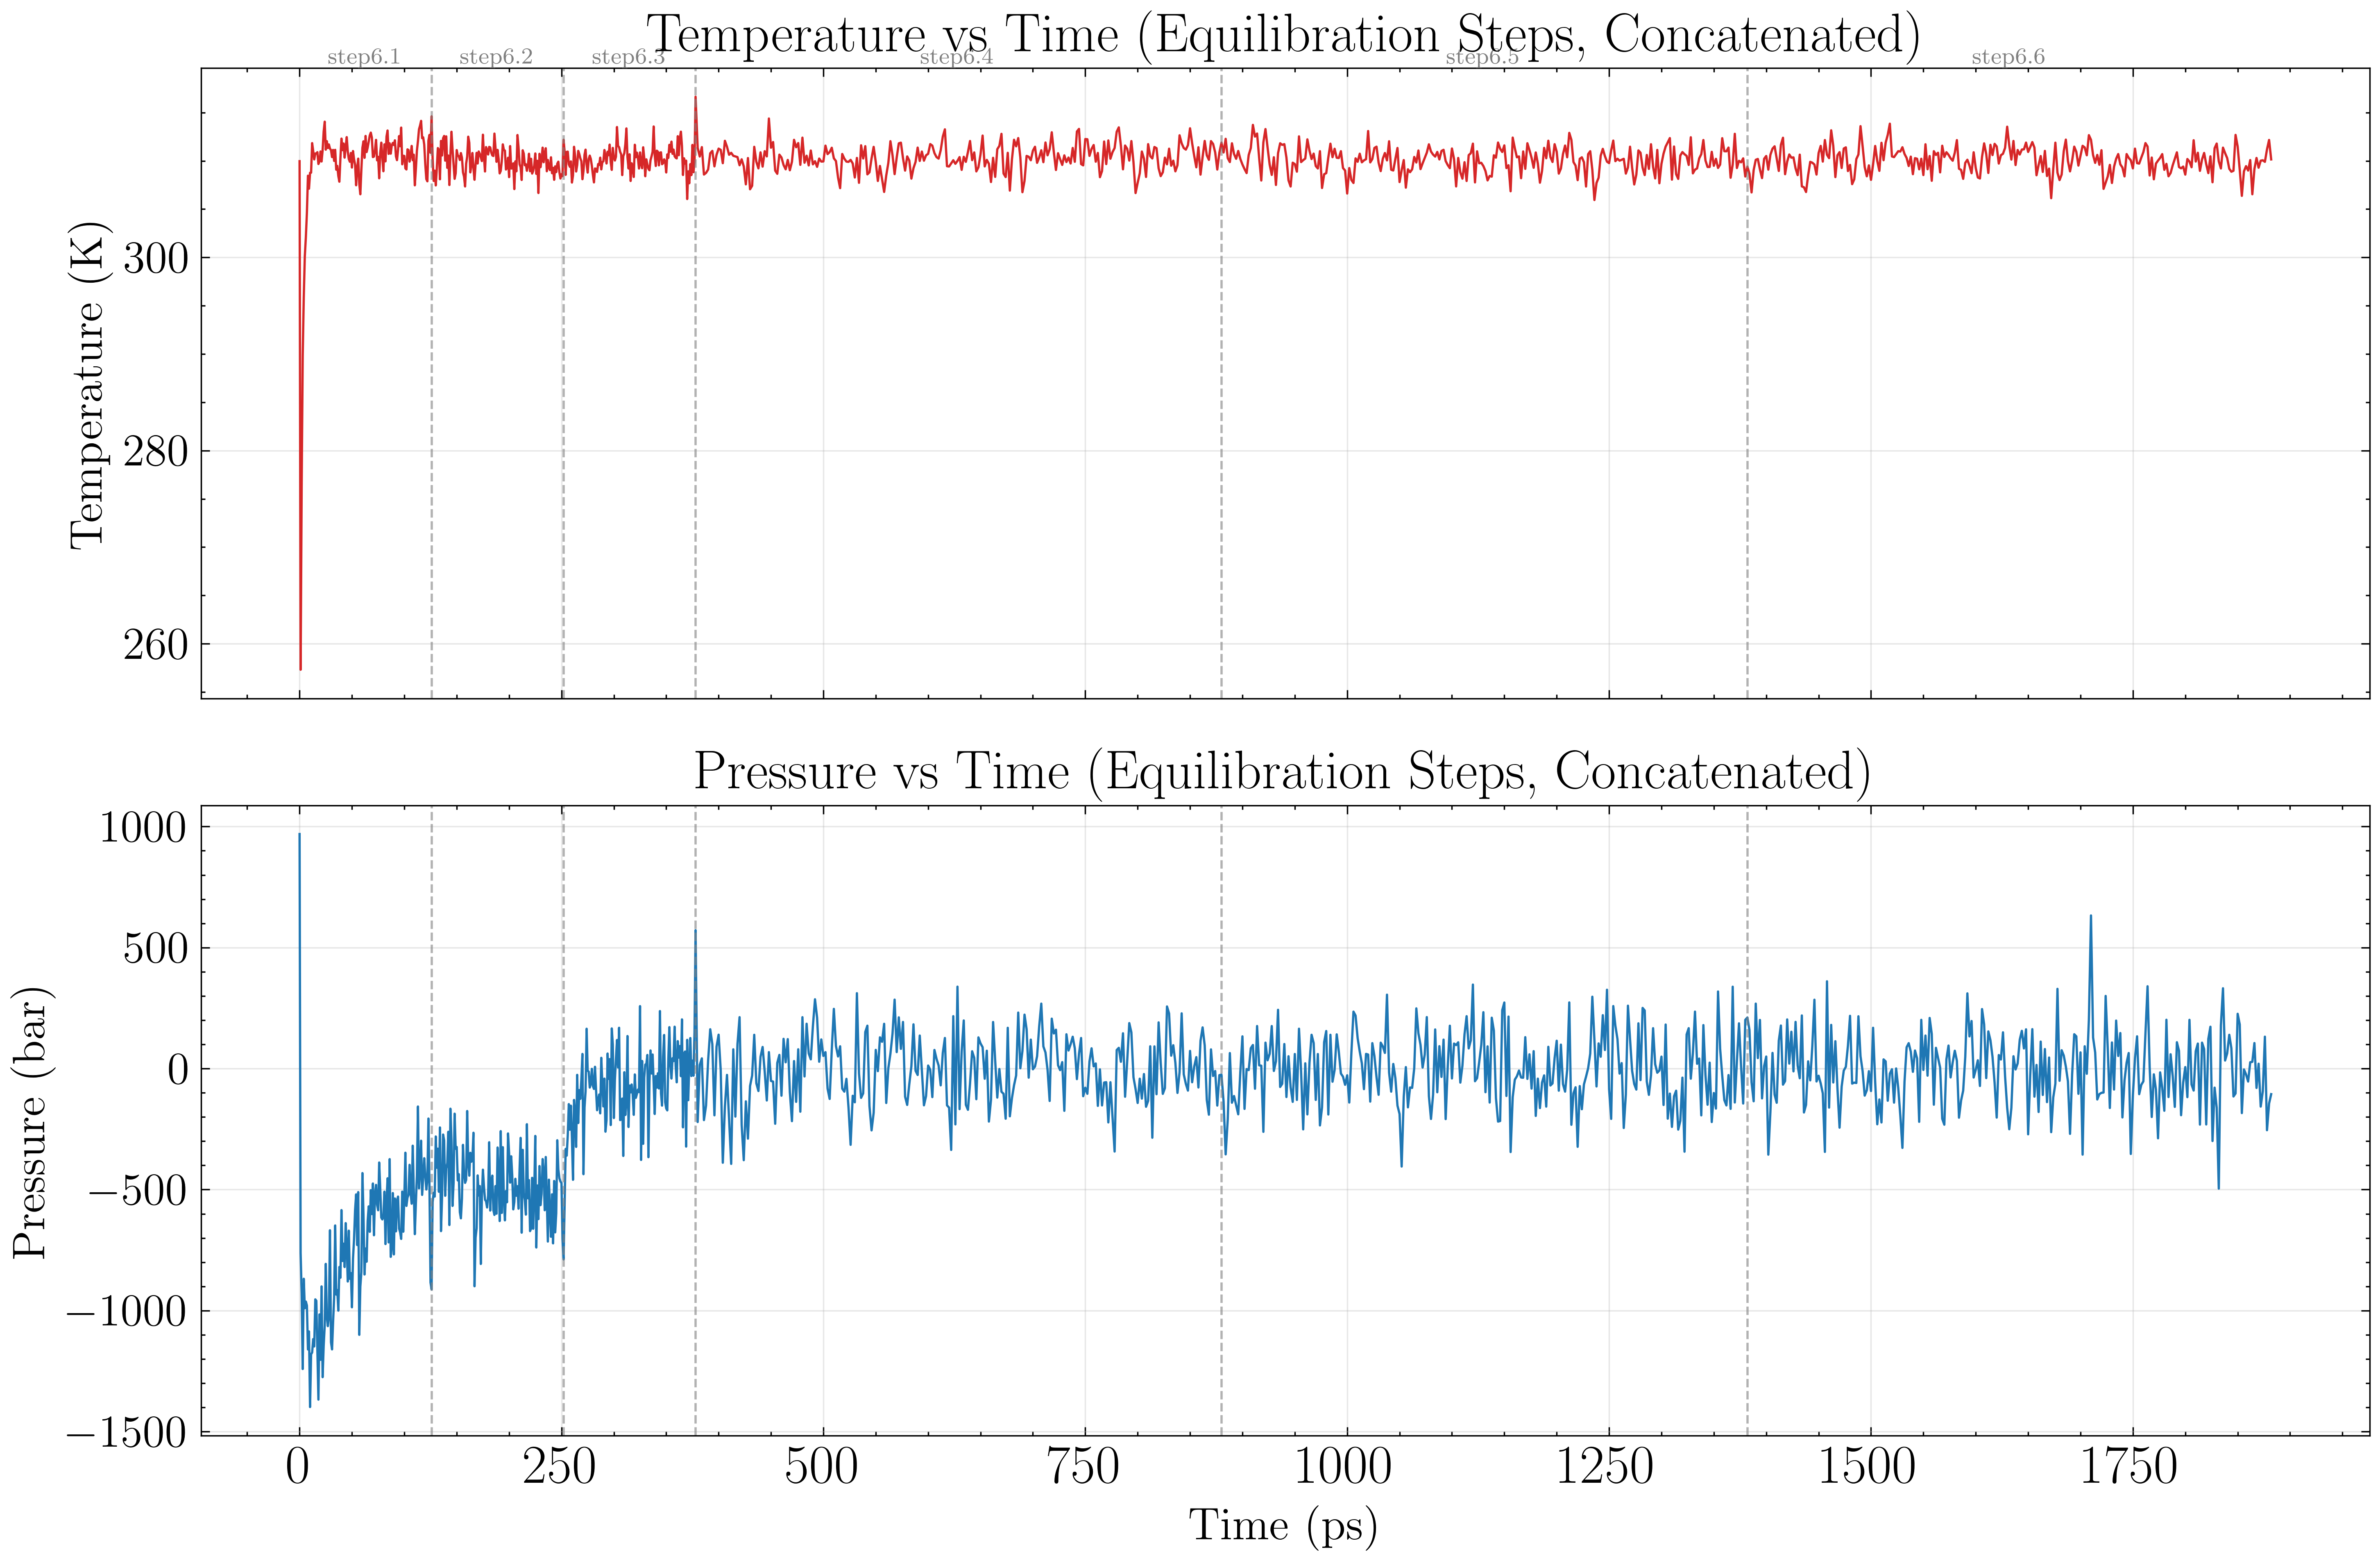

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use("science")

# Concatenate consecutive steps into a single continuous time series
# Offset each step's time so it follows the previous one
concat_time = []
concat_temp = []
concat_press = []
time_offset = 0.0

for time, temp, press in zip(all_time, all_temp, all_press):
    concat_time.append(time + time_offset)
    concat_temp.append(temp)
    concat_press.append(press)
    time_offset += time[-1] - time[0] + (time[1] - time[0])  # advance by step duration + dt

concat_time = np.concatenate(concat_time)
concat_temp = np.concatenate(concat_temp)
concat_press = np.concatenate(concat_press)

# Add vertical lines at step boundaries
step_boundaries = []
t_offset = 0.0
for time in all_time[:-1]:
    t_offset += time[-1] - time[0] + (time[1] - time[0])
    step_boundaries.append(t_offset)

fig, (ax_temp, ax_press) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_temp.plot(concat_time, concat_temp, lw=0.8, color="tab:red")
ax_press.plot(concat_time, concat_press, lw=0.8, color="tab:blue")

for bnd in step_boundaries:
    ax_temp.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax_press.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)

# Annotate step labels at the top of the temperature plot
t_offset = 0.0
for i, (time, label) in enumerate(zip(all_time, step_labels)):
    mid = t_offset + (time[-1] - time[0]) / 2
    ax_temp.text(mid, ax_temp.get_ylim()[1], label, ha="center", va="bottom",
                 fontsize=8, color="gray")
    t_offset += time[-1] - time[0] + (time[1] - time[0])

ax_temp.set_title("Temperature vs Time (Equilibration Steps, Concatenated)")
ax_temp.set_ylabel("Temperature (K)")
ax_temp.grid(True, alpha=0.3)

ax_press.set_title("Pressure vs Time (Equilibration Steps, Concatenated)")
ax_press.set_xlabel("Time (ps)")
ax_press.set_ylabel("Pressure (bar)")
ax_press.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Box vectors

It is also advisable to verify that the box vectors have stabilized, ensuring a stable lateral area of the membrane (Box-X and Box-Y).

Note that box vectors only change during NPT ensemble dynamics. in NVT ensemble, all boundary conditions are fixed by definition.

Processed step6.3.edr -> step6.3_box.xvg
Processed step6.4.edr -> step6.4_box.xvg
Processed step6.5.edr -> step6.5_box.xvg
Processed step6.6.edr -> step6.6_box.xvg


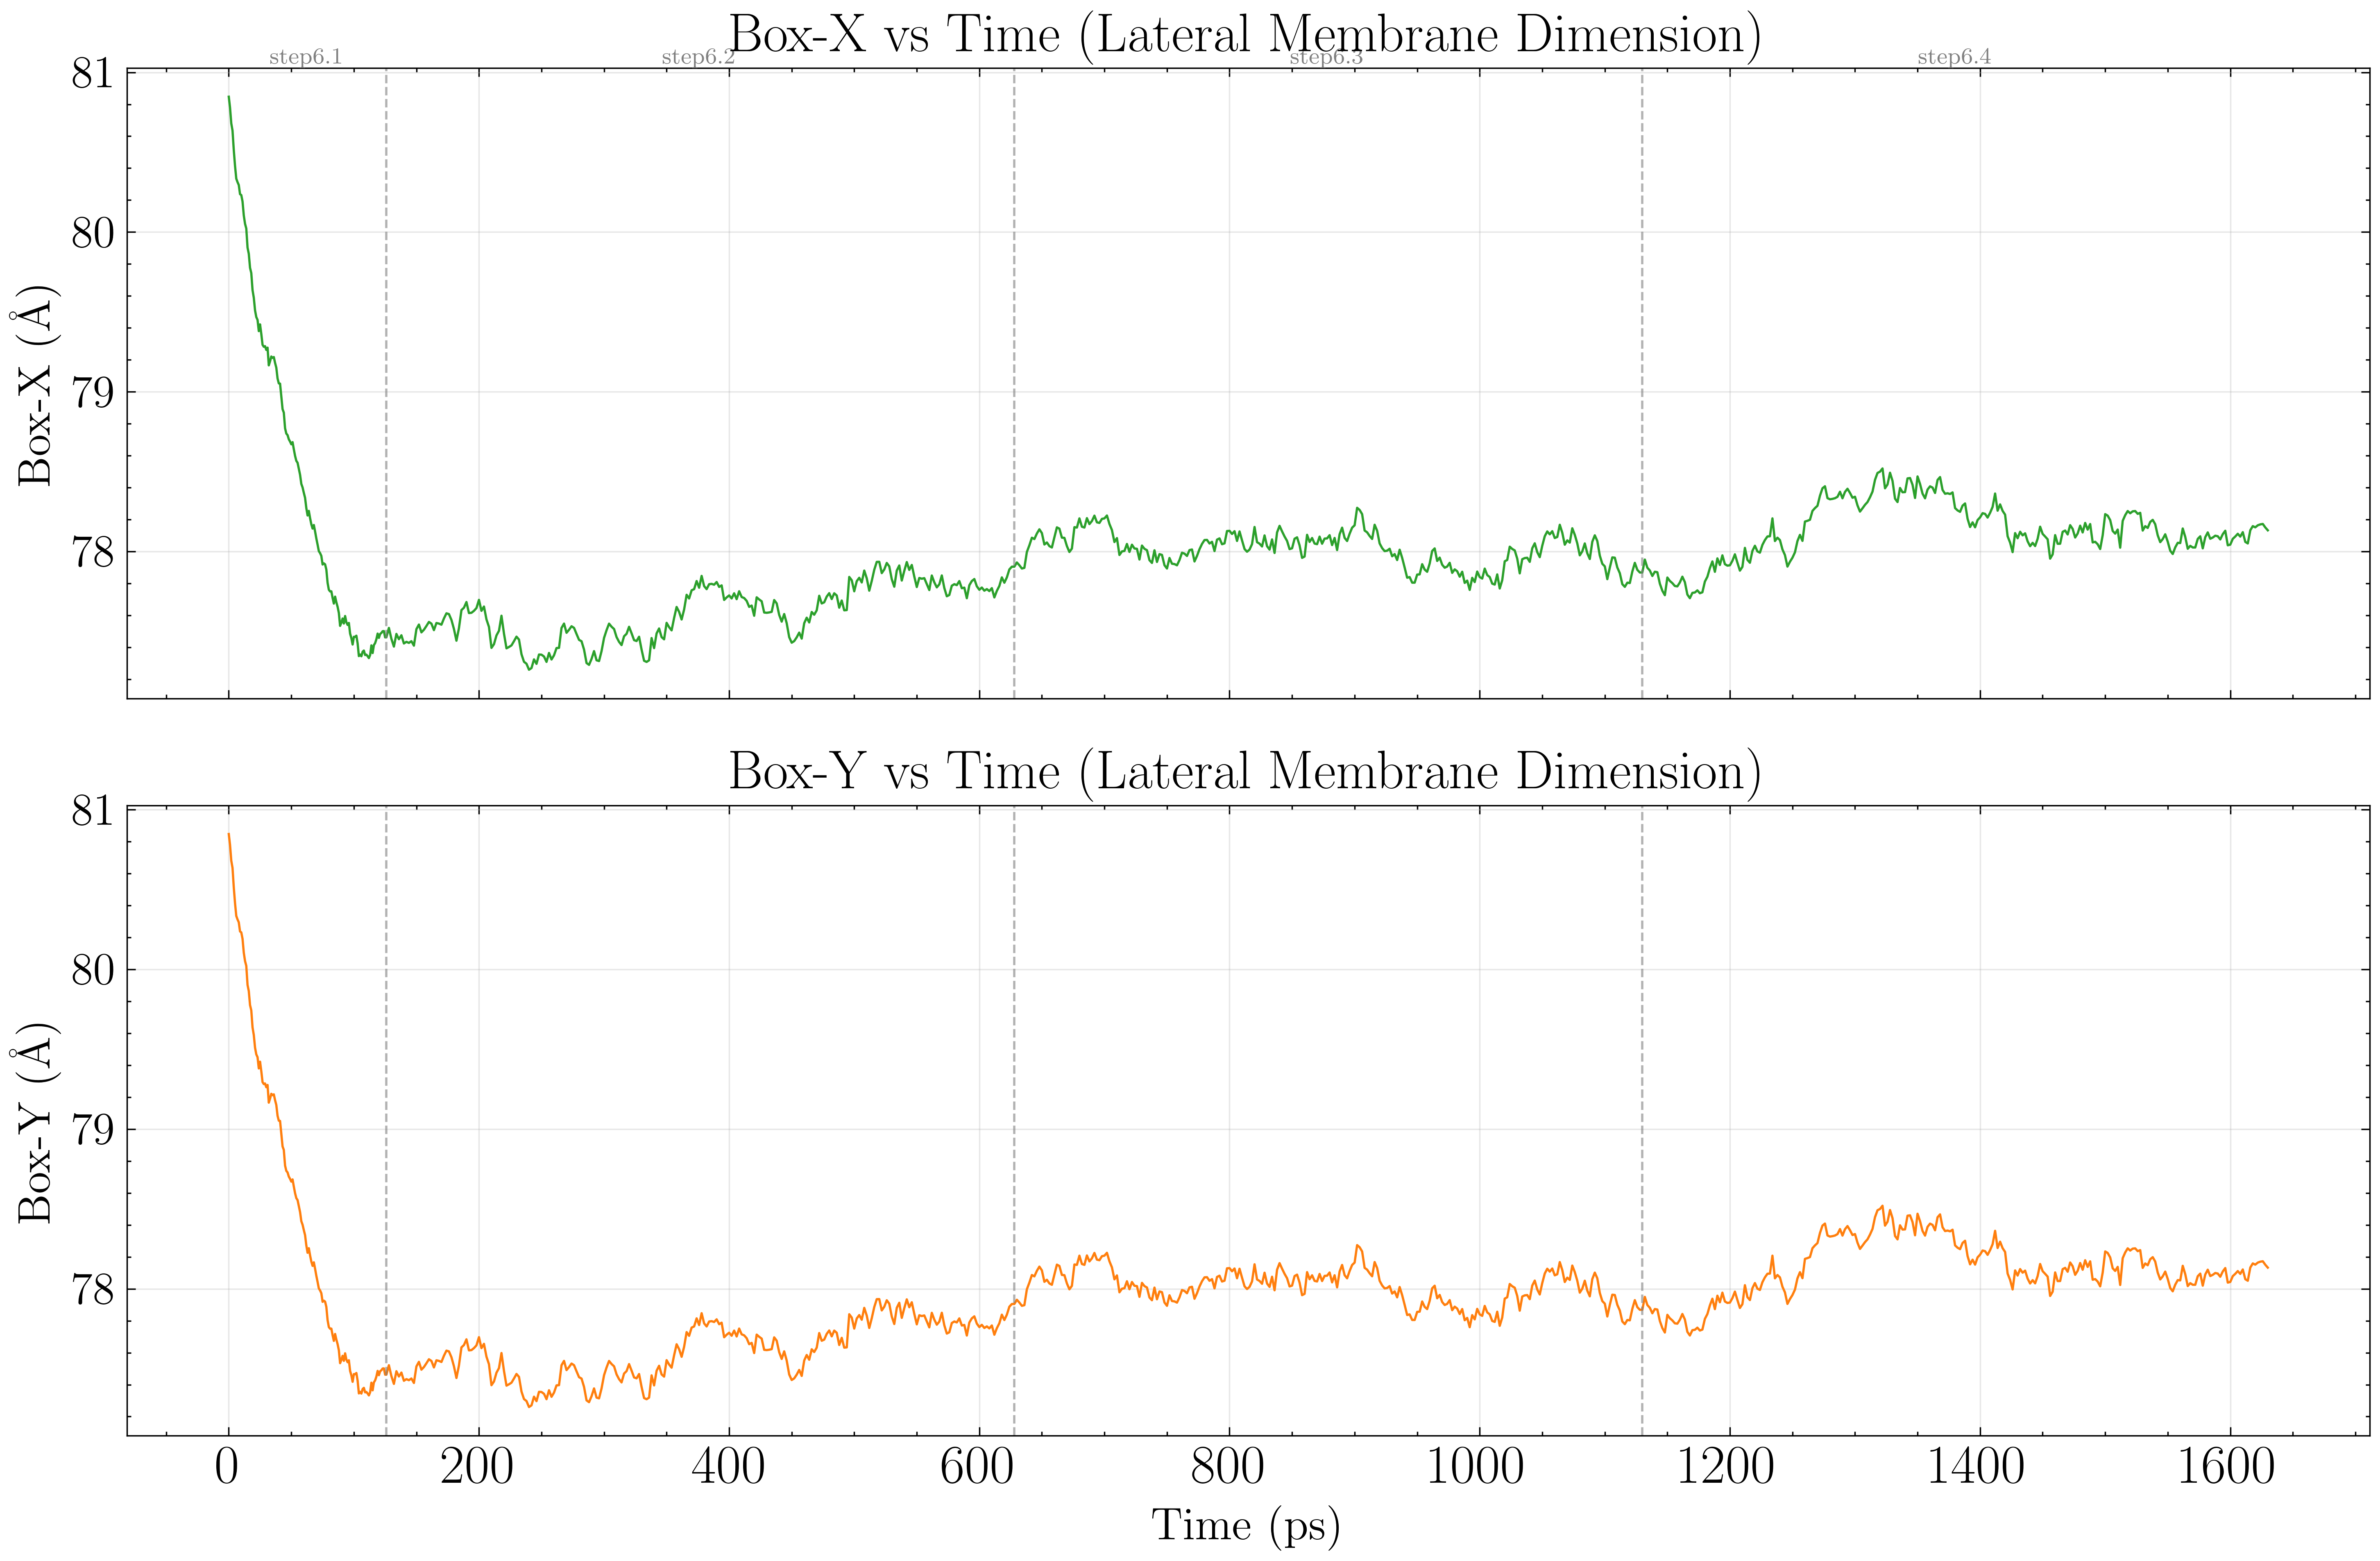

In [ ]:
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use("science")
# Extract Box-X and Box-Y from each equilibration step .edr file
all_box_time = []
all_boxx = []
all_boxy = []

for edr_file in edr_files[2:]:
    step_name = os.path.splitext(edr_file)[0]
    xvg_file = f"{step_name}_box.xvg"

    result = subprocess.run(
        ["gmx", "energy", "-f", edr_file, "-o", xvg_file],
        input=b"Box-X\nBox-Y\n0\n",
        capture_output=True,
    )

    if result.returncode != 0:
        print(f"gmx energy failed for {edr_file}:")
        print(result.stderr.decode(errors="replace"))
        continue
    else:
        print(f"Processed {edr_file} -> {xvg_file}")

    try:
        data = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    except Exception as e:
        print(f"Could not load {xvg_file}: {e}")
        continue

    # data[0]=time (ps), data[1]=Box-X (nm), data[2]=Box-Y (nm)
    all_box_time.append(data[0])
    all_boxx.append(data[1])
    all_boxy.append(data[2])

# Build concatenated time axis independently for box data
concat_box_time = []
box_time_offset = 0.0
for t in all_box_time:
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    concat_box_time.append(t + box_time_offset)
    box_time_offset += t[-1] - t[0] + dt

concat_box_time = np.concatenate(concat_box_time)
concat_boxx = np.concatenate(all_boxx)
concat_boxy = np.concatenate(all_boxy)

# Step boundary positions on this time axis
box_boundaries = []
t_off = 0.0
for t in all_box_time[:-1]:
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    t_off += t[-1] - t[0] + dt
    box_boundaries.append(t_off)

# Plot
fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_x.plot(concat_box_time, concat_boxx * 10, lw=0.8, color="tab:green")   # nm -> Å
ax_y.plot(concat_box_time, concat_boxy * 10, lw=0.8, color="tab:orange")

for bnd in box_boundaries:
    ax_x.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax_y.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)

# Step labels
t_off = 0.0
for t, label in zip(all_box_time, step_labels):
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    mid = t_off + (t[-1] - t[0]) / 2
    ax_x.text(mid, ax_x.get_ylim()[1], label, ha="center", va="bottom",
              fontsize=8, color="gray")
    t_off += t[-1] - t[0] + dt

ax_x.set_title("Box-X vs Time (Lateral Membrane Dimension)")
ax_x.set_ylabel("Box-X (Å)")
ax_x.grid(True, alpha=0.3)

ax_y.set_title("Box-Y vs Time (Lateral Membrane Dimension)")
ax_y.set_xlabel("Time (ps)")
ax_y.set_ylabel("Box-Y (Å)")
ax_y.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Production PP

First, let's test to ensure that the concatenation worked.

In [18]:
import os
data_dir = os.environ.get("HOME", "/home/daneel")
data_dir = os.path.join(data_dir, "gitrepos/gromacs_sims/Antimicrobial_Peptides/Ku04AMP01_Membrane_Bilayer/simulation")



In [19]:
import MDAnalysis as mda


u = mda.Universe(os.path.join(data_dir, "step7_1.tpr"), os.path.join(data_dir, "traj_prod.xtc"),os.path.join(data_dir, "step7_11_100ns.part0002.xtc"))
#u = mda.Universe(os.path.join(data_dir, "traj_dry.tpr"), os.path.join(data_dir, "traj_dry.xtc"))

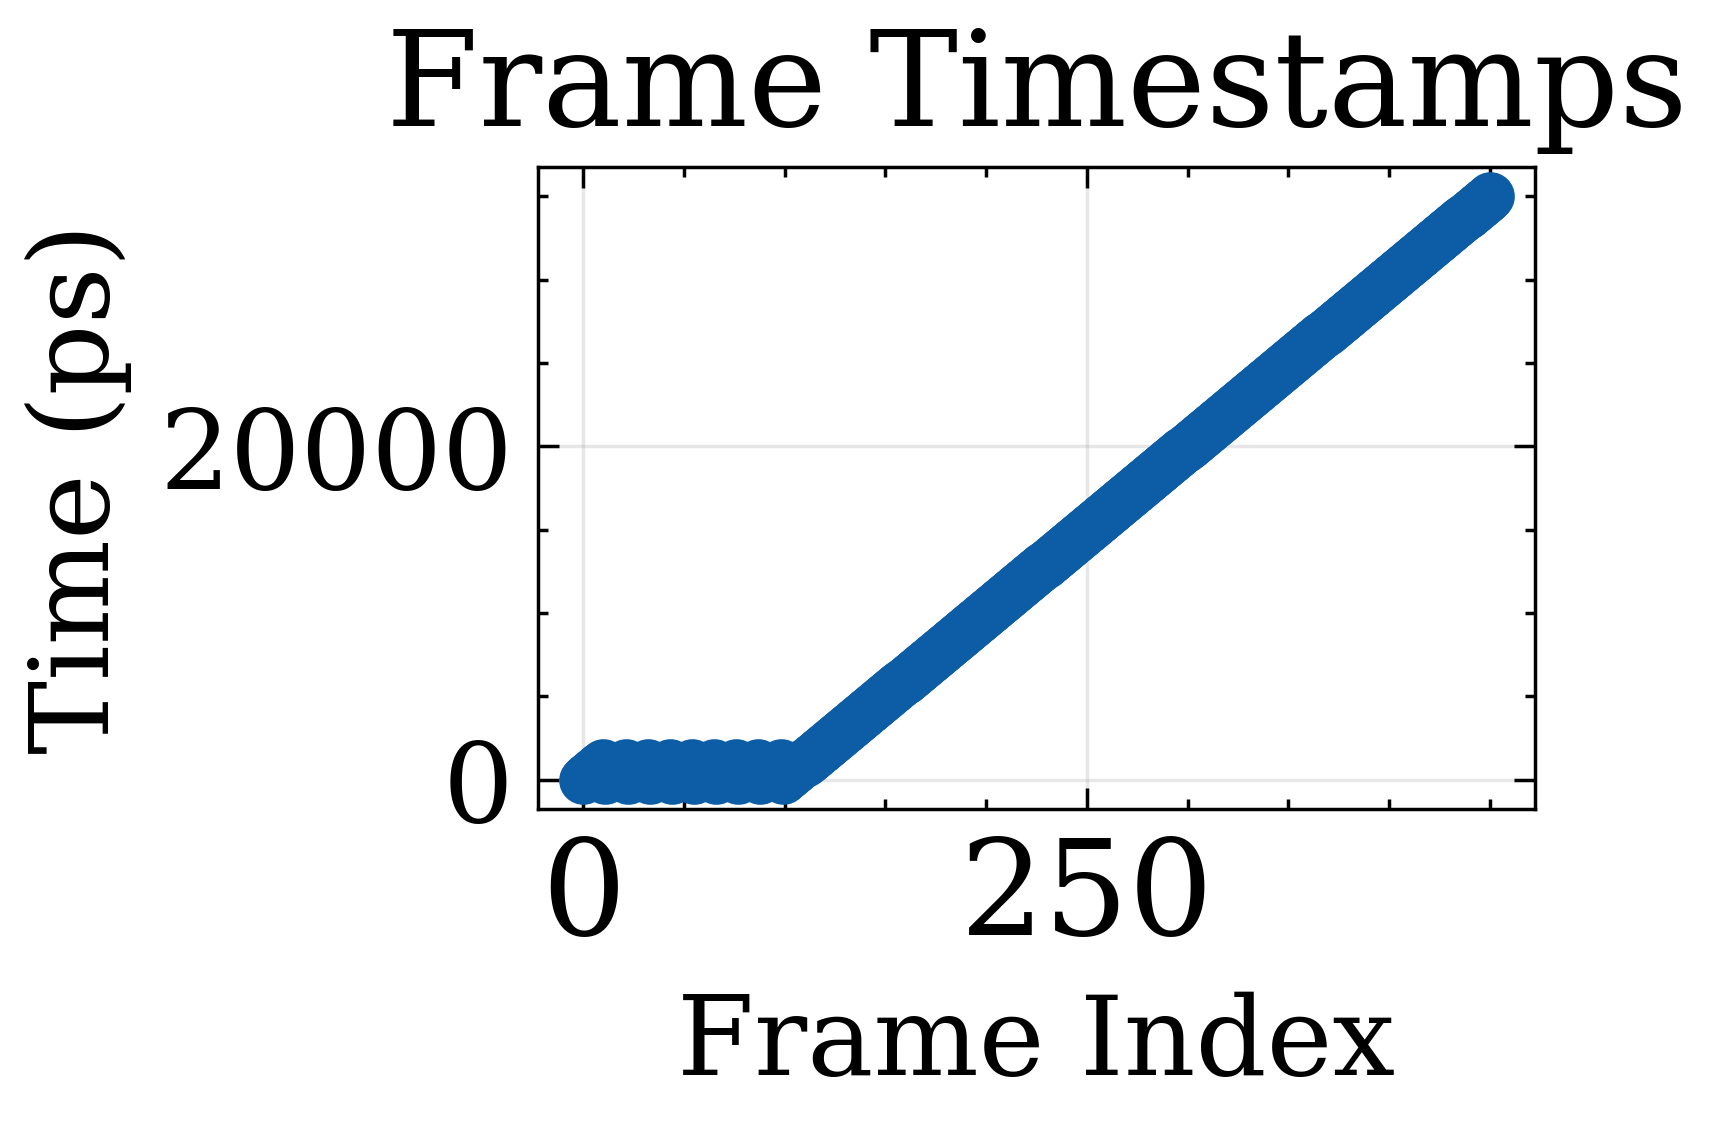

Min dt: -1000.00 ps, Max dt: 100.00 ps
Monotonically increasing: False
Total frames: 451, Time range: 0.00 – 35000.00 ps


In [20]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
# First, check the timestamps for each frame
timestamps = [ts.time for ts in u.trajectory]  # in ps

plt.plot(timestamps, marker="o", linestyle="")
plt.title("Frame Timestamps")
plt.xlabel("Frame Index")
plt.ylabel("Time (ps)")
plt.grid(True, alpha=0.3)
plt.show()

# Check if timestamps are monotonically increasing (expected after correct trjcat)
import numpy as np
diffs = np.diff(timestamps)
print(f"Min dt: {diffs.min():.2f} ps, Max dt: {diffs.max():.2f} ps")
print(f"Monotonically increasing: {np.all(diffs > 0)}")
print(f"Total frames: {len(timestamps)}, Time range: {timestamps[0]:.2f} – {timestamps[-1]:.2f} ps")

The concatenation clearly failed — timestamps repeat from 0–10000 ps about 10 times instead of being continuous. This is a classic trjcat issue where it concatenated the files but didn't offset the timestamps.


Fix the timestamps in Python without re-running gromacs:

In [22]:
# Refined timestamp logic
total_actual_time = 41000.0  # The physical simulation time in ps (41 ns)
n_frames = len(u.trajectory)

# Create a linear mapping from 0 to 41000 ps across the existing frames
corrected_times = np.linspace(0, total_actual_time, n_frames)

print(f"Total Frames: {n_frames}")
print(f"Mapped Time Range: {corrected_times[0]:.0f} to {corrected_times[-1]:.0f} ps")

Total Frames: 451
Mapped Time Range: 0 to 41000 ps


## Verify that membrane is oriented with z-axis vertical


Although this is standard convention, we **should** check this.


The definitive check is a number density profile — if z is the normal, you'll see distinct layers (water → LPS headgroups → acyl chains → phospholipid headgroups → water) along z but not along x or y. Add this cell to confirm:

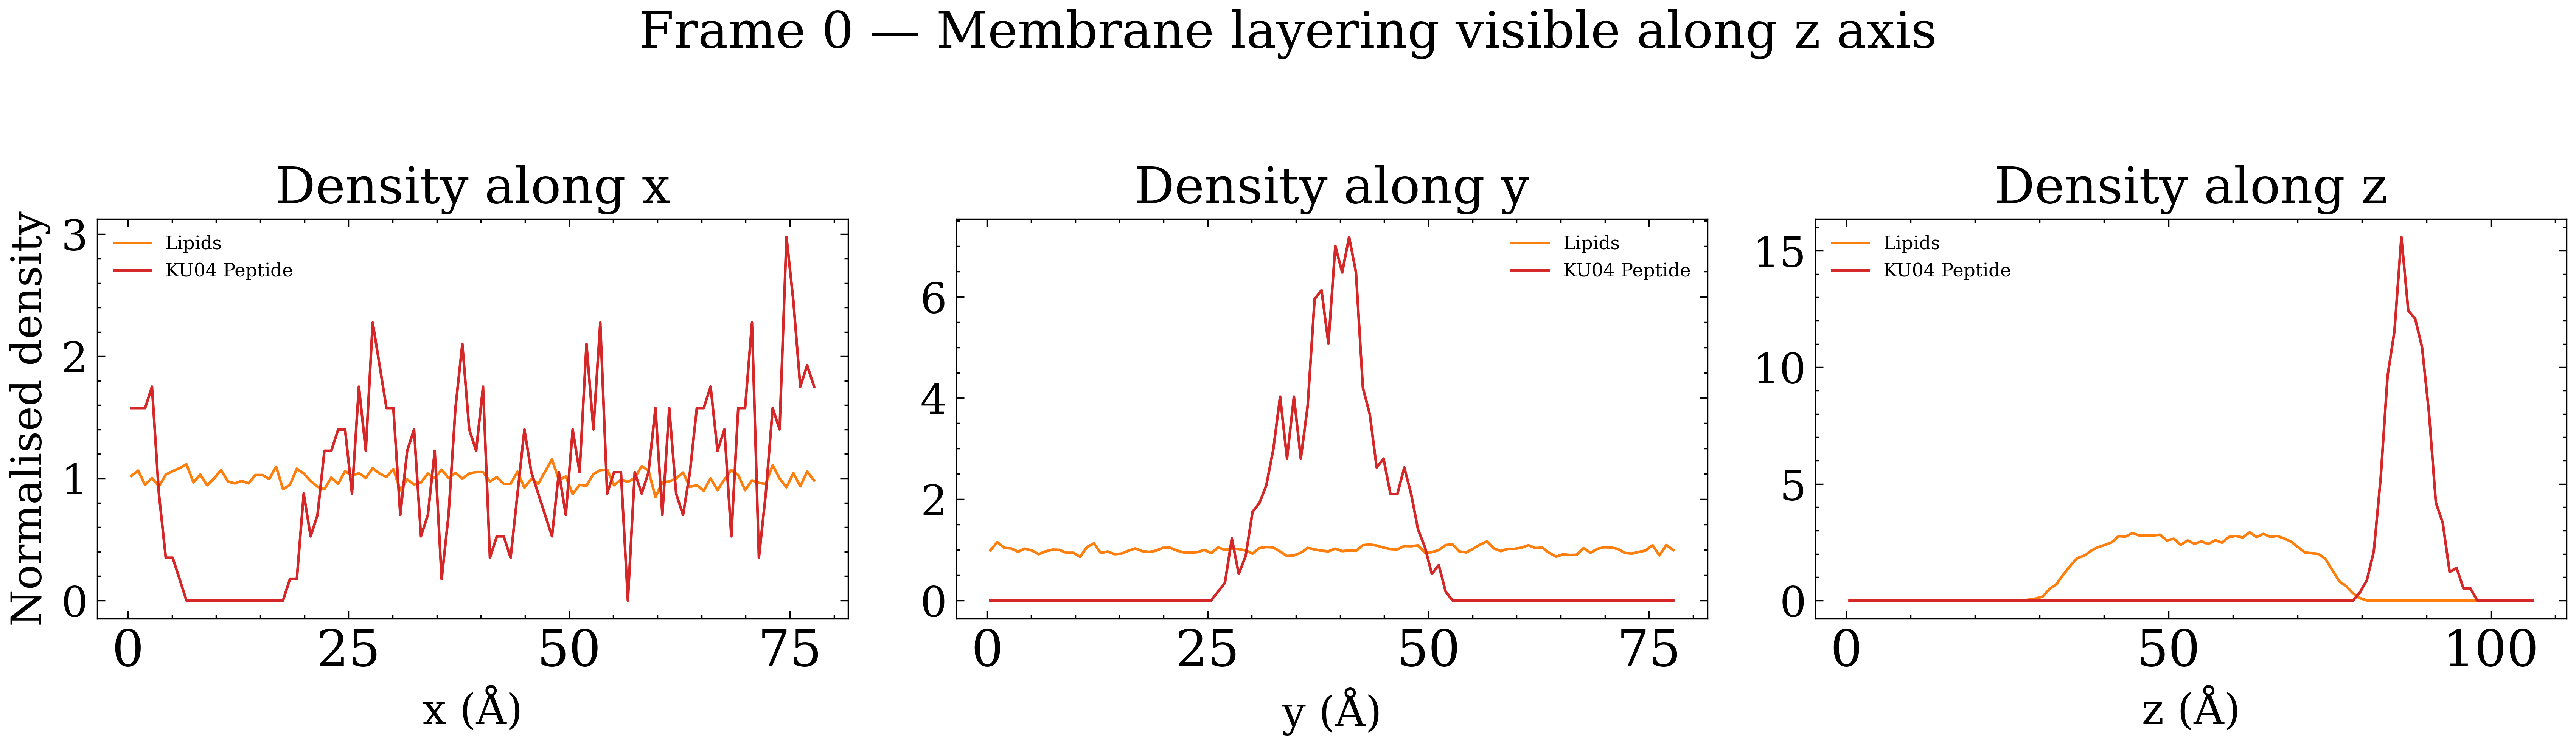

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
u.trajectory[0]
bins = 100

# Updated selections based on topol.top
sel_lip = u.select_atoms("resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL")
sel_ku04 = u.select_atoms("not (resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL W WF SOL ION NA SOD CL CLA TIP3)")

box = u.dimensions[:3] # Å

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
labels = ["x", "y", "z"]

# Components to plot
components = [
    (sel_lip, "Lipids", "tab:orange"),
    (sel_ku04, "KU04 Peptide", "tab:red"),
]

for col, (ax, dim) in enumerate(zip(axes, range(3))):
    for ag, name, color in components:
        if len(ag) == 0:
            continue
        
        pos = ag.positions[:, dim]
        counts, edges = np.histogram(pos, bins=bins, range=(0, box[dim]))
        centres = 0.5 * (edges[:-1] + edges[1:])
        
        # Avoid division by zero if a component is missing in a specific plane (unlikely for density)
        if counts.max() > 0:
            ax.plot(centres, counts / counts.mean(), label=name, lw=1.0, color=color)

    ax.set_xlabel(f"{labels[col]} (Å)")
    ax.set_ylabel("Normalised density" if col == 0 else "")
    #ax.set_ylim(0, 1.5)
    ax.set_title(f"Density along {labels[col]}")
    ax.legend(fontsize=7)

plt.suptitle("Frame 0 — Membrane layering visible along z axis", y=1.02)
plt.tight_layout()
plt.show()

The lipid layers are uniform in x and y, and the ku04 shows a spike in z above the lipids. As expected.

## Get RMSDs

- **Old code (no superposition)**: RMSD starts at ~138 Å and stays 138–145 Å — the entire signal is a **PBC artifact**. The membrane's center of mass jumped across the periodic box at some point (very common with broken `trjcat` trajectories), so the raw atom-to-atom distances are dominated by that ~138 Å offset, not by conformational changes.

- **New code (`superposition=True`)**: Least-squares fits (translates + rotates) the membrane onto the reference before computing RMSD, removing the rigid-body offset. The result (0–30 Å) is the actual conformational RMSD.

So the old plot was physically meaningless. The new one is correct.

That said, the spikiness in the new plot is still a concern — it's a sign of residual PBC imaging issues (individual molecules jumping across box boundaries within the concatenated trajectory). For a membrane, the standard fix is to also **unwrap** molecules per-frame before computing RMSD: 

The `transformations.unwrap` call fixes atoms that jump across the periodic boundary mid-trajectory, which is what causes those sharp spikes. It runs on-the-fly for each frame without modifying the file on disk.

Made changes.

In [24]:
from multiprocessing import Pool, cpu_count
from functools import partial
from MDAnalysis.analysis import rms
from MDAnalysis import transformations as trans
from tqdm.notebook import tqdm
import numpy as np
# --- Config ---
tpr_file = os.path.join(data_dir, "step7_1.tpr")
xtc_file = os.path.join(data_dir, "traj_prod.xtc")
xtc_file2 = os.path.join(data_dir, "step7_11_100ns.part0002.xtc")

# If using martini, select by exclusion of standard Martini 3 membrane, water, and ion residues
# Example: ku04_sel = "not (resname POPE OYPE PYPG PVCL2 DPPE DPPG CHOL W WF SOL ION NA SOD CL CLA TIP3)"
#ku04_sel = "resindex 0-35" 
ku04_sel = "not (resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL W WF SOL ION NA SOD CL CLA TIP3)"

# If using martini, select by inclusion of standard Martini 3 membrane residues
# Example: memb_sel = "resname POPE OYPE PYPG PVCL2 DPPE DPPG"
#memb_sel = "resindex 36-235"
memb_sel = "resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL"
# Reload universe with center_in_box + wrap (no unwrap: that needs sequential
# reads from frame 0 and is incompatible with block-parallel random access).
# traj_whole.xtc is already molecule-whole, so this is sufficient.
u = mda.Universe(tpr_file, xtc_file, xtc_file2)
membrane = u.select_atoms(memb_sel)
ku04     = u.select_atoms(ku04_sel)
workflow = [
    trans.center_in_box(membrane, wrap=True),
    trans.wrap(u.select_atoms("all"), compound="residues"),
]
u.trajectory.add_transformations(*workflow)

# Reference = frame 0 after imaging
u.trajectory[0]
ref_memb = membrane.positions.copy()
ref_ku04  = ku04.positions.copy()

# --- Split trajectory into blocks (one per core) ---
n_jobs   = min(cpu_count(), 8)
n_frames = u.trajectory.n_frames
n_fpb    = n_frames // n_jobs   # frames per block
blocks   = [range(i * n_fpb, (i + 1) * n_fpb) for i in range(n_jobs - 1)]
blocks.append(range((n_jobs - 1) * n_fpb, n_frames))
print(f"Frames: {n_frames}  |  Cores: {n_jobs}  |  ~{n_fpb} frames/block")

# --- Worker function ---
def rmsd_block(block_frames, tpr_file, xtc_file, xtc_file2, memb_sel, ku04_sel, ref_memb, ref_ku04):
    """Each worker loads its own Universe and iterates its slice sequentially."""
    import MDAnalysis as mda
    from MDAnalysis.analysis import rms
    from MDAnalysis import transformations as trans

    u_w    = mda.Universe(tpr_file, xtc_file, xtc_file2)
    memb_w = u_w.select_atoms(memb_sel)
    ku04_w = u_w.select_atoms(ku04_sel)
    wf = [
        trans.center_in_box(memb_w, wrap=True),
        trans.wrap(u_w.select_atoms("all"), compound="residues"),
    ]
    u_w.trajectory.add_transformations(*wf)

    res_memb, res_ku04 = [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        res_memb.append(rms.rmsd(memb_w.positions, ref_memb, superposition=True))
        res_ku04.append(rms.rmsd(ku04_w.positions,  ref_ku04,  superposition=True))
    u_w.trajectory.close() # Explicitly close to avoid __del__ race    
    return res_memb, res_ku04

# --- Run in parallel ---
run_block = partial(rmsd_block,
                    tpr_file=tpr_file, xtc_file=xtc_file, xtc_file2=xtc_file2,
                    memb_sel=memb_sel, ku04_sel=ku04_sel,
                    ref_memb=ref_memb, ref_ku04=ref_ku04)

with Pool(n_jobs) as pool:
    block_results = list(tqdm(pool.imap(run_block, blocks),
                            total=n_jobs, desc="Blocks", unit="block"))

# --- Combine in order ---
rmsd_memb = [v for memb_res, _       in block_results for v in memb_res]
rmsd_ku04  = [v for _,       ku04_res  in block_results for v in ku04_res]
print(f"Done. {len(rmsd_memb)} RMSD values computed.")



Frames: 451  |  Cores: 8  |  ~56 frames/block


Blocks:   0%|          | 0/8 [00:00<?, ?block/s]

Done. 451 RMSD values computed.


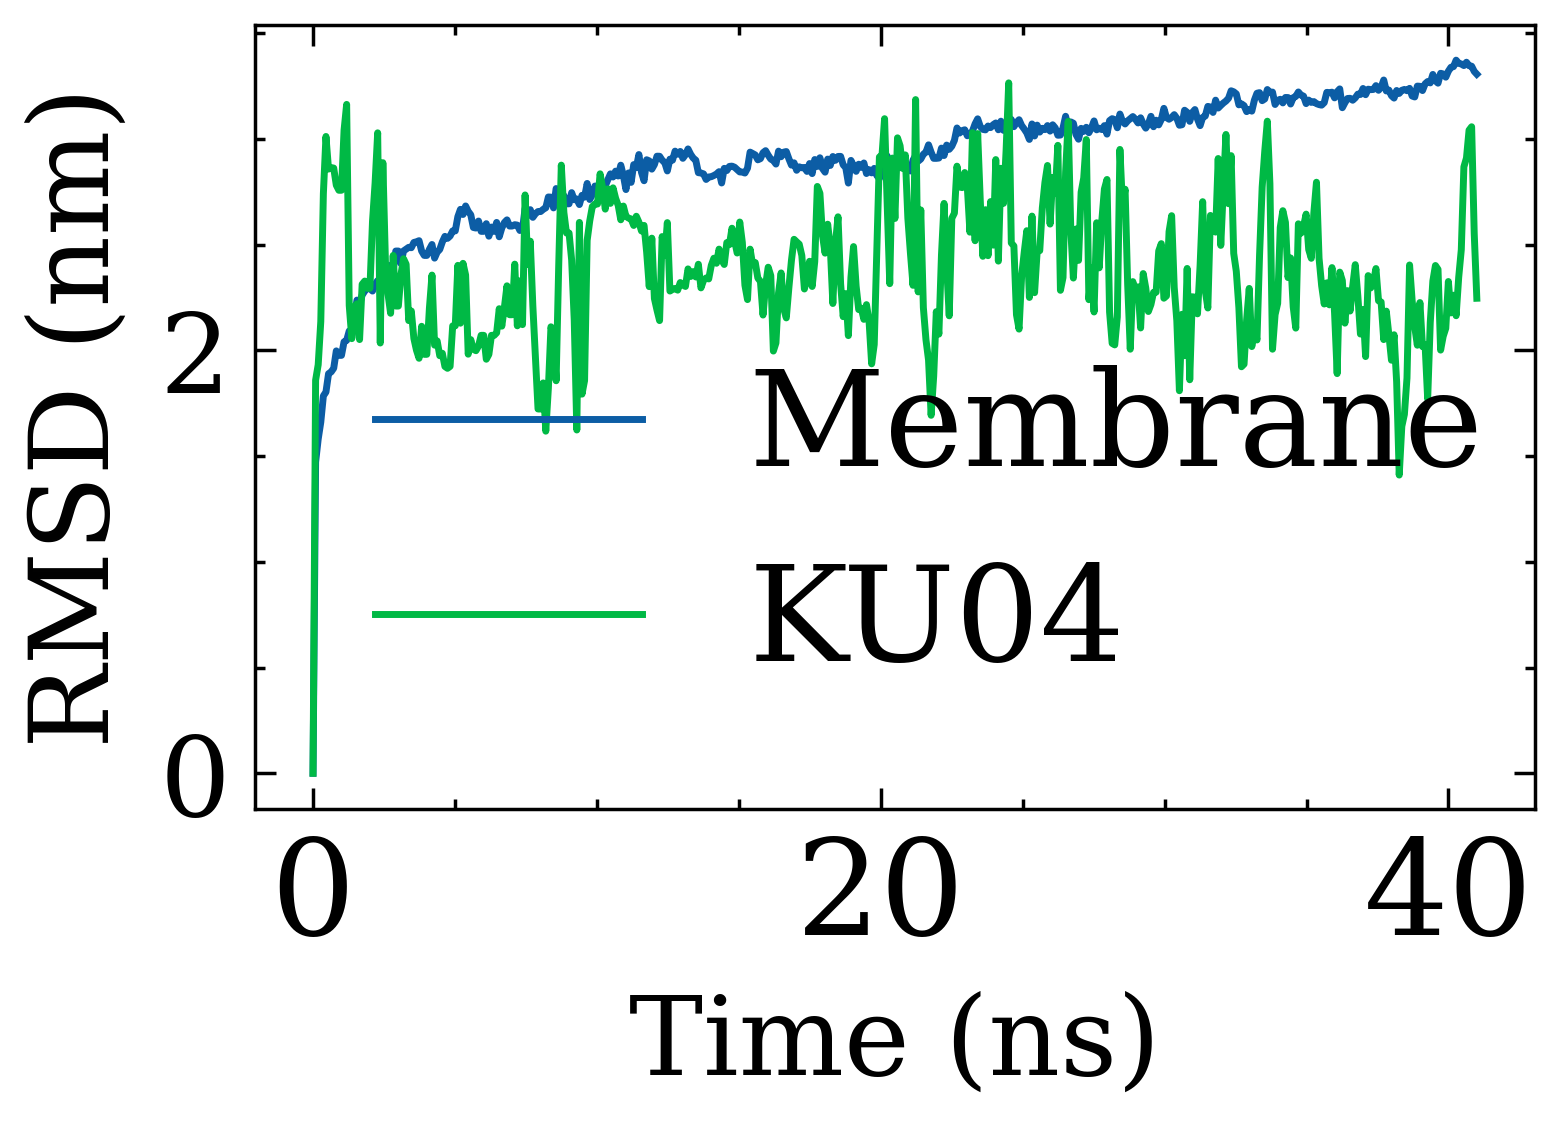

In [25]:
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False

plt.plot(corrected_times/1000, np.array(rmsd_memb)/10, label="Membrane")
plt.plot(corrected_times/1000, np.array(rmsd_ku04)/10, label="KU04")
plt.legend()
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
#plt.grid(True, alpha=0.6)
plt.show()

In [26]:
print(f"Atoms: {len(membrane)}")
print(f"Resnames: {np.unique(membrane.resnames)}")

Atoms: 24916
Resnames: ['OYPE' 'PMPE' 'PMPG' 'POPE' 'PVCL2' 'PYPG' 'QMPE']


## Peptide center-of-mass depth (MOST IMPORTANT)

This is the primary penetration metric.

Measure:

COM of PMBN
vs
membrane midplane (or phosphate plane).

Plot:

z_peptide(t) - z_membrane_center(t)

Interpretation:

* constant near-water value → no binding

* stable near-headgroup region → adsorption

* gradual inward motion → insertion

* crossing midplane → translocation

### Get headgroup distance 

You can verify the exact headgroup positions for your specific system by calculating the Z-position of the Phosphorus (P) atoms relative to the midplane.

In GROMACS/CHARMM36, Phosphorus atoms (name P) are located in the headgroups of all your lipids (PMPE, POPE, PYPG, etc.). By tracking their COM, you get the objective "surface" of the membrane.

In [27]:
# Selection for all phosphorus atoms in the membrane. When using martini CG, try replacing with "name PO4" for the phosphate beads
phosphorus_sel = "(resindex 36-235) and name P"

def p_depth_block(block_frames, tpr_file, xtc_file, xtc_file2, memb_sel, p_sel):
    import MDAnalysis as mda
    from MDAnalysis import transformations as trans
    u_w = mda.Universe(tpr_file, xtc_file, xtc_file2)
    memb_w = u_w.select_atoms(memb_sel)
    p_w = u_w.select_atoms(p_sel)
    
    # Imaging
    wf = [trans.center_in_box(memb_w, wrap=True), trans.wrap(u_w.atoms)]
    u_w.trajectory.add_transformations(*wf)

    z_p_upper, z_p_lower, z_mid = [], [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        mid = memb_w.center_of_mass()[2]
        p_pos = p_w.positions[:, 2]
        
        # Split P atoms into upper and lower based on midplane
        z_p_upper.append(p_pos[p_pos > mid].mean())
        z_p_lower.append(p_pos[p_pos < mid].mean())
        z_mid.append(mid)
        
    u_w.trajectory.close()
    return z_p_upper, z_p_lower, z_mid

# Run in parallel (reuse your blocks and n_jobs)
run_p = partial(p_depth_block, tpr_file=tpr_file, xtc_file=xtc_file, xtc_file2=xtc_file2,
                memb_sel=memb_sel, p_sel=phosphorus_sel)

with Pool(n_jobs) as pool:
    p_results = list(tqdm(pool.imap(run_p, blocks), total=n_jobs, desc="P-depth"))

# Average distances from midplane
dz_p_upper = np.array([v for r in p_results for v in r[0]]) - np.array([v for r in p_results for v in r[2]])
dz_p_lower = np.array([v for r in p_results for v in r[1]]) - np.array([v for r in p_results for v in r[2]])

print(f"Verified Phosphorus Planes: {dz_p_upper.mean():.2f} Å and {dz_p_lower.mean():.2f} Å")

P-depth:   0%|          | 0/8 [00:00<?, ?it/s]

Verified Phosphorus Planes: 19.28 Å and -19.26 Å


### Get z-COM of peptide

In [28]:
import numpy as np
from tqdm.notebook import tqdm
from functools import partial
from multiprocessing import Pool

def depth_block(block_frames, tpr_file, xtc_file,xtc_file2, memb_sel, ku04_sel):
    """Worker: z-COM of KU04 and membrane midplane per frame."""
    import MDAnalysis as mda
    from MDAnalysis import transformations as trans

    u_w     = mda.Universe(tpr_file, xtc_file, xtc_file2)
    memb_w  = u_w.select_atoms(memb_sel)
    ku04_w  = u_w.select_atoms(ku04_sel)
    
    # Standard imaging to ensure COM calculations aren't broken by PBC
    wf = [
        trans.center_in_box(memb_w, wrap=True),
        trans.wrap(u_w.atoms, compound="residues"),
    ]
    u_w.trajectory.add_transformations(*wf)

    z_ku04, z_mid = [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        z_mid.append(memb_w.center_of_mass()[2])
        z_ku04.append(ku04_w.center_of_mass()[2])
        
    u_w.trajectory.close()
    return z_ku04, z_mid

# Prepare partial function for parallel execution
run_depth = partial(depth_block,
                    tpr_file=tpr_file, xtc_file=xtc_file, xtc_file2=xtc_file2,
                    memb_sel=memb_sel, ku04_sel=ku04_sel)

print(f"Computing penetration depth on {n_jobs} cores …")
with Pool(n_jobs) as pool:
    depth_results = list(tqdm(pool.imap(run_depth, blocks),
                            total=n_jobs, desc="Blocks", unit="block"))

# Combine results
z_ku04 = np.array([v for r in depth_results for v in r[0]])
z_mid  = np.array([v for r in depth_results for v in r[1]])

# Depth relative to membrane midplane
# (positive = upper leaflet side, negative = lower leaflet side)
dz_ku04 = z_ku04 - z_mid

print(f"Done. Mean KU04 depth relative to midplane: {dz_ku04.mean():.1f} Å")

Computing penetration depth on 8 cores …


Blocks:   0%|          | 0/8 [00:00<?, ?block/s]

Done. Mean KU04 depth relative to midplane: 29.6 Å


### Plot z-COM relative to membrane COM and headgroup planes

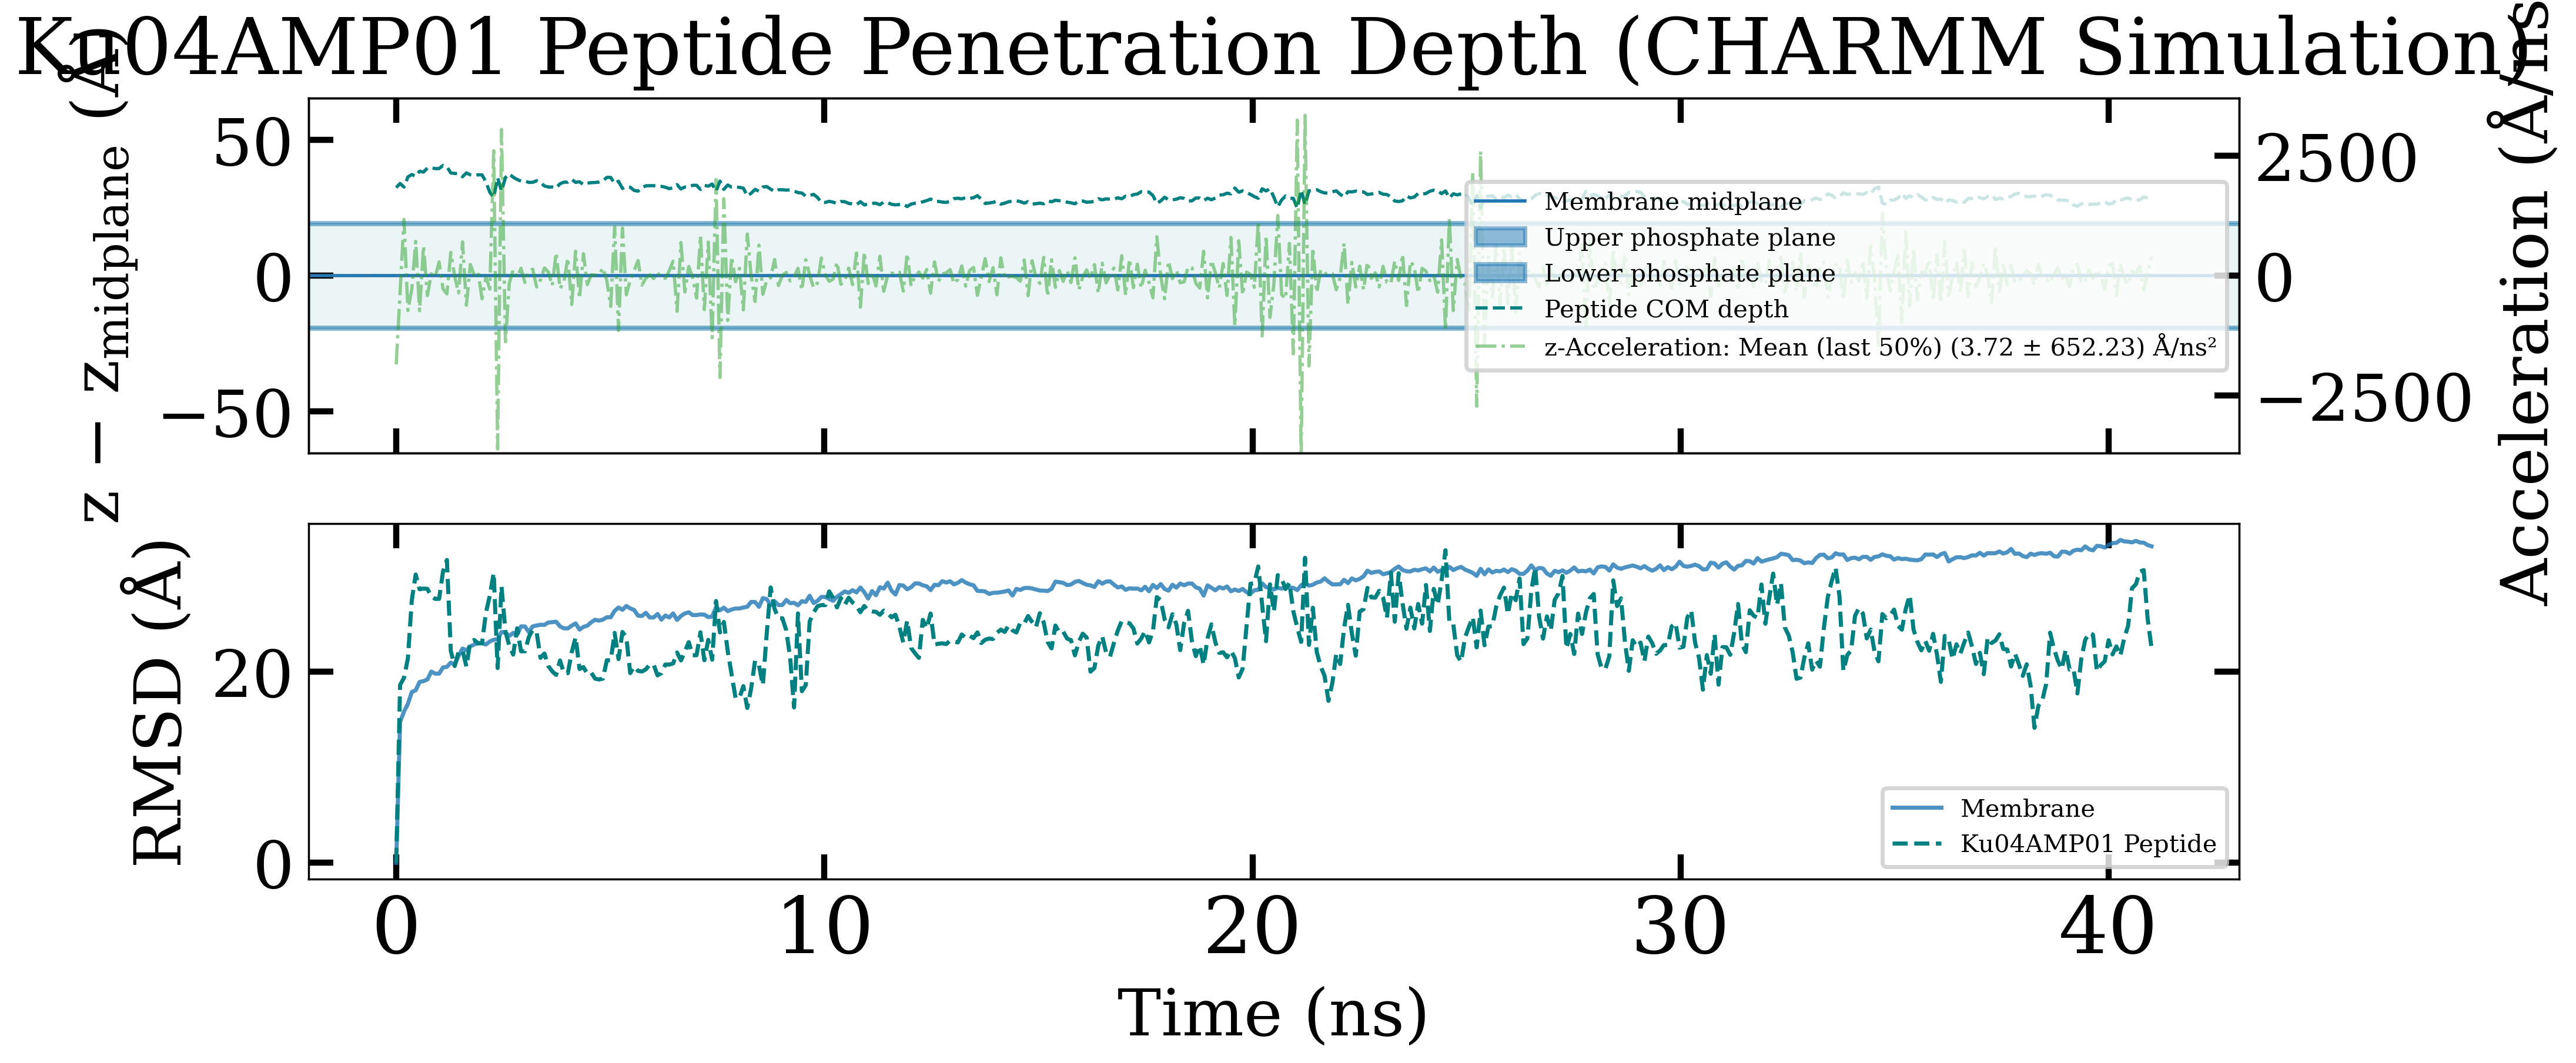

In [29]:
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
t_ns = corrected_times / 1000

fig, (ax_up, ax_down) = plt.subplots(2, 1, figsize=(9, 4), sharex=True, tight_layout=True, gridspec_kw={'height_ratios': [1, 1]})


ax = ax_up  # Use the lower axis for plotting
# Mark the membrane center line
ax.axhline(0, color="tab:blue", lw=0.8, label="Membrane midplane")

# UPDATED: Verified Phosphorus headgroup planes
upper_p = dz_p_upper.mean()
lower_p = dz_p_lower.mean()

upper_p_std = dz_p_upper.std()
lower_p_std = dz_p_lower.std()
ax.axhspan(upper_p - upper_p_std, upper_p + upper_p_std, alpha=0.5, color="tab:blue", label="Upper phosphate plane")
ax.axhspan(lower_p - lower_p_std, lower_p + lower_p_std, alpha=0.5, color="tab:blue", label="Lower phosphate plane")

ax.axhspan(lower_p, upper_p, alpha=0.08, color="teal")

# Plot the Peptide depth
ax.plot(t_ns, dz_ku04, lw=0.8, color="teal", label="Peptide COM depth", ls="--")

ax.set_title("Ku04AMP01 Peptide Penetration Depth (CHARMM Simulation)")
ax.set_ylabel(r"z − z$_{\text{midplane}}$ (Å)")
ax.minorticks_off()
ax_ylim = np.sort(list(ax.get_ylim())) * 1.5
ax.set_ylim(-ax_ylim[1], ax_ylim[1])

# Add a secondary y-axis to show acceleration of penetration depth (optional)
ax2 = ax.twinx()
ax2.minorticks_off()

# Get derivativs after spline interpolation
spline = UnivariateSpline(t_ns, dz_ku04, s=0)
dz_ku04_dt = spline.derivative(n=1)(t_ns)
dz_ku04_d2t = spline.derivative(n=2)(t_ns)

# Calculate mean and std over only the last 50% of the simulation
last_50_percent_mask = t_ns >= (t_ns[-1] - 0.5 * (t_ns[-1] - t_ns[0]))
mean_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].mean()
std_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].std()


ax2.plot(t_ns, dz_ku04_d2t, lw=0.8, color="tab:green", alpha=0.5, label=f"z-Acceleration: Mean (last 50%) ({mean_accel_last_50_percent:.2f} ± {std_accel_last_50_percent:.2f}) Å/ns²", ls="-.")
ax2.axhline(dz_ku04_d2t.mean(), color="gray", lw=0.8, ls="--", alpha=0.1)
ax2.set_ylabel(r"Acceleration (Å/ns²)")
# Align the zeros of ax and ax2
ax2_ylim = np.sort(list(ax2.get_ylim()))
ax2.set_ylim(-ax2_ylim[1], ax2_ylim[1])

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="center right", fontsize=6, frameon=True, fancybox=True)


ax = ax_down
ax.minorticks_off()
ax.set_xlabel("Time (ns)")
ax.plot(t_ns, np.array(rmsd_memb), label="Membrane", alpha=0.8, color="tab:blue")
ax.plot(t_ns, np.array(rmsd_ku04), label="Ku04AMP01 Peptide", color="teal", ls="--")
ax.set_ylabel("RMSD (Å)")
ax.legend(loc="lower right", fontsize=6, frameon=True, fancybox=True)

for ax in [ax_up, ax_down, ax2]:
    ax.tick_params(axis='both', which='major', length=6, width=1.5)


plt.show()

Looks like gradual inward motion, followed by steady state adsorption above the membrane at around 1 nanometer. Every time there is a negative force pulling it towards the membrane, a positive force pushes back. 

In [30]:
last_half = dz_ku04_d2t[last_50_percent_mask]
up_f, down_f = last_half[last_half >= 0].mean(), last_half[last_half < 0].mean()
up_f_err, down_f_err = last_half[last_half >= 0].std(), last_half[last_half < 0].std()
print(f"Mean upward acceleration (last 50%): {up_f:.2f} ± {up_f_err:.2f} Å/ns²")
print(f"Mean downward acceleration (last 50%): {down_f:.2f} ± {down_f_err:.2f} Å/ns²")

Mean upward acceleration (last 50%): 374.64 ± 539.44 Å/ns²
Mean downward acceleration (last 50%): -380.56 ± 523.88 Å/ns²


The average upward force is more-or-less equal to the average downward force, indicating steady state height at such short times.

Probably needs to run for longer with martini.

## Hydrogen Bond Analysis

In [31]:
u = mda.Universe(tpr_file, xtc_file, xtc_file2)
print(len(u.select_atoms("name H*")))
print(set(u.atoms.resnames))

42702
{'PMPE', 'TYR', 'PVCL2', 'ARG', 'PYPG', 'THR', 'POPE', 'ASP', 'PRO', 'ASN', 'GLY', 'VAL', 'PMPG', 'CLA', 'ALA', 'OYPE', 'ILE', 'GLN', 'TIP3', 'SOD', 'LYS', 'GLU', 'QMPE', 'SER'}


In [64]:
import MDAnalysis as mda
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

u = mda.Universe(tpr_file, xtc_file, xtc_file2)

hba = HydrogenBondAnalysis(
    u,
    donors_sel="protein",
    hydrogens_sel="protein and name H*",
    acceptors_sel="resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG and name O*",
)

print("Protein atoms:", u.select_atoms("protein").n_atoms)
print("Hydrogen atoms:", u.select_atoms("protein and name H*").n_atoms)
print("Acceptor atoms:", u.select_atoms("resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG and name O*").n_atoms)

hba.run(start=0, stop=5)

print(hba.results.hbonds[:10])

Protein atoms: 571
Hydrogen atoms: 288
Acceptor atoms: 1712
[]


/usr/local/lib/python3.12/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:743: UserWarning: No hydrogen bonds were found given d-a cutoff of 3.0 between Donor, protein, and Acceptor, resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG and name O*.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 150 between Donor, protein, and Acceptor, resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG and name O*.
  warnings.warn(


In [65]:
u = mda.Universe(tpr_file, xtc_file, xtc_file2)

print("Number of bonds:", len(u.bonds))

protein = u.select_atoms("protein")

print("Protein bonds:", len(protein.bonds))

Number of bonds: 52792
Protein bonds: 574


In [69]:
from MDAnalysis.lib.distances import distance_array

u = mda.Universe(tpr_file, xtc_file, xtc_file2)

u.trajectory[-1]

donors = u.select_atoms("""
protein and
(name N NZ NE NH1 NH2 ND2 NE2 OG OG1 OH NE1)
""")

acceptors = u.select_atoms("""
resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG
and name O*
""")

D = distance_array(
    donors.positions,
    acceptors.positions,
    box=u.dimensions
)

print("Minimum donor-acceptor distance:", D.min())

Minimum donor-acceptor distance: 2.597310983364186


In [67]:
pairs = np.where(D < 3.5)

print(len(pairs[0]))

0


A minimum donor–acceptor distance of 5.5 Å means there are no peptide donor atoms within hydrogen-bonding distance of any lipid oxygen in that frame. Later frames are better.

In [70]:
from MDAnalysis.lib.distances import distance_array

u = mda.Universe(tpr_file, xtc_file, xtc_file2)
u.trajectory[-1]

donors = u.select_atoms("""
protein and
(name N NZ NE NH1 NH2 ND2 NE2 OG OG1 OH NE1)
""")

acceptors = u.select_atoms("""
resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG
and name O*
""")

D = distance_array(
    donors.positions,
    acceptors.positions,
    box=u.dimensions
)

pairs = np.where(D < 3.2)

print("Candidate H-bond pairs:", len(pairs[0]))

for i, j in zip(*pairs):
    print(
        donors[i].resname,
        donors[i].resid,
        donors[i].name,
        " --> ",
        acceptors[j].resname,
        acceptors[j].resid,
        acceptors[j].name,
        f"{D[i,j]:.2f} Å"
    )

Candidate H-bond pairs: 11
LYS 3 NZ  -->  PMPE 42 O14 2.64 Å
LYS 3 NZ  -->  PMPE 46 O32 2.73 Å
LYS 7 NZ  -->  PMPG 190 O14 2.60 Å
LYS 8 N  -->  POPE 164 O12 3.19 Å
LYS 8 NZ  -->  POPE 164 O32 2.87 Å
LYS 11 NZ  -->  PMPE 39 O14 2.74 Å
LYS 11 NZ  -->  PYPG 147 OC3 2.76 Å
ARG 18 NE  -->  OYPE 129 O13 2.71 Å
ARG 18 NH1  -->  PMPE 48 O14 2.81 Å
ARG 18 NH2  -->  PMPE 48 O32 3.08 Å
SER 24 OG  -->  PMPG 192 OC2 2.83 Å


In [71]:
import MDAnalysis
print(MDAnalysis.__version__)

2.9.0


In [72]:
u = mda.Universe(tpr_file, xtc_file, xtc_file2)

u.trajectory[-1]

for atom in u.select_atoms("protein and name NZ NH1 NH2 NE OG N")[:15]:

    print()
    print(atom.resname, atom.resid, atom.name)

    for b in atom.bonded_atoms:
        print("   ", b.name, b.type)


ASP 1 N
    CY C
    HN H
    CA CT1

ASN 2 N
    C C
    HN H
    CA CT1

LYS 3 N
    C C
    HN H
    CA CT1

LYS 3 NZ
    CE CT2
    HZ1 HC
    HZ2 HC
    HZ3 HC

ALA 4 N
    C C
    HN H
    CA CT1

LYS 5 N
    C C
    HN H
    CA CT1

LYS 5 NZ
    CE CT2
    HZ1 HC
    HZ2 HC
    HZ3 HC

SER 6 N
    C C
    HN H
    CA CT1

SER 6 OG
    CB CT2
    HG1 H

LYS 7 N
    C C
    HN H
    CA CT1

LYS 7 NZ
    CE CT2
    HZ1 HC
    HZ2 HC
    HZ3 HC

LYS 8 N
    C C
    HN H
    CA CT1

LYS 8 NZ
    CE CT2
    HZ1 HC
    HZ2 HC
    HZ3 HC

ARG 9 N
    C C
    HN H
    CA CT1

ARG 9 NE
    CD CT2
    HE HC
    CZ C


In [73]:
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

u = mda.Universe(tpr_file, xtc_file, xtc_file2)
u.trajectory[-1]

hba = HydrogenBondAnalysis(
    u,
    hydrogens_sel="protein and name H*",
    acceptors_sel="resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG and name O*",
)

hba._prepare()

print("Donor-H pairs:", len(hba._donors))
print("Hydrogens    :", len(hba._hydrogens))

for d, h in zip(hba._donors[:20], hba._hydrogens[:20]):
    print(d.resname, d.resid, d.name, " -- ", h.name)

Donor-H pairs: 288
Hydrogens    : 288
ASP 1 CAY  --  HY1
ASP 1 CAY  --  HY2
ASP 1 CAY  --  HY3
ASP 1 N  --  HN
ASP 1 CA  --  HA
ASP 1 CB  --  HB1
ASP 1 CB  --  HB2
ASN 2 N  --  HN
ASN 2 CA  --  HA
ASN 2 CB  --  HB1
ASN 2 CB  --  HB2
ASN 2 ND2  --  HD21
ASN 2 ND2  --  HD22
LYS 3 N  --  HN
LYS 3 CA  --  HA
LYS 3 CB  --  HB1
LYS 3 CB  --  HB2
LYS 3 CG  --  HG1
LYS 3 CG  --  HG2
LYS 3 CD  --  HD1


In [74]:
hba = HydrogenBondAnalysis(
    u,
    donors_sel="""
    protein and (
    name N NZ NE NH1 NH2 ND2 OG OG1 OH NE1
    )
    """,
    hydrogens_sel="""
    protein and (
    name HN HZ1 HZ2 HZ3
    HE
    HH11 HH12 HH21 HH22
    HD21 HD22
    HG1 HG
    )
    """,
    acceptors_sel="""
    resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG
    and name O*
    """
)

hba._prepare()

for d,h in zip(hba._donors[:30], hba._hydrogens[:30]):
    print(d.name, h.name)

N HN
N HN
ND2 HD21
ND2 HD22
N HN
NZ HZ2
NZ HZ1
NZ HZ3
N HN
N HN
NZ HZ1
NZ HZ2
NZ HZ3
N HN
OG HG1
N HN
NZ HZ2
NZ HZ1
NZ HZ3
N HN
NZ HZ3
NZ HZ1
NZ HZ2
N HN
NE HE
NH1 HH12
NH1 HH11
NH2 HH22
NH2 HH21
N HN


Checking D-H-A angles towards the end of the trajectory.

In [75]:
import numpy as np
import MDAnalysis as mda
from MDAnalysis.lib.distances import distance_array

# ------------------------------------------------------------
# Load system
# ------------------------------------------------------------

u = mda.Universe(tpr_file, xtc_file, xtc_file2)
u.trajectory[-1]

# ------------------------------------------------------------
# Chemically valid donor atoms
# ------------------------------------------------------------

donors = u.select_atoms("""
protein and (
name N NZ NE NH1 NH2 ND2 OG OG1 OH NE1
)
""")

acceptors = u.select_atoms("""
resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG
and name O*
""")

# ------------------------------------------------------------
# Find nearby donor-acceptor pairs
# ------------------------------------------------------------

D = distance_array(
    donors.positions,
    acceptors.positions,
    box=u.dimensions
)

pairs = np.argwhere(D < 3.2)

print(f"\nCandidate donor-acceptor pairs: {len(pairs)}\n")

# ------------------------------------------------------------
# Angle routine
# ------------------------------------------------------------

def dha_angle(donor, hydrogen, acceptor):

    # vectors pointing away from H
    v1 = donor.position - hydrogen.position
    v2 = acceptor.position - hydrogen.position

    v1 /= np.linalg.norm(v1)
    v2 /= np.linalg.norm(v2)

    c = np.clip(np.dot(v1, v2), -1.0, 1.0)

    return np.degrees(np.arccos(c))


# ------------------------------------------------------------
# Examine every pair
# ------------------------------------------------------------

for i, j in pairs:

    donor = donors[i]
    acceptor = acceptors[j]

    hydrogens = [
        atom for atom in donor.bonded_atoms
        if atom.element == "H"
    ]

    if len(hydrogens) == 0:
        continue

    print("="*70)

    print(
        f"{donor.resname:4s} {donor.resid:3d} {donor.name:4s}"
        f"  -->  "
        f"{acceptor.resname:5s} {acceptor.resid:4d} {acceptor.name:4s}"
        f"   D-A = {D[i,j]:5.2f} Å"
    )

    best = 0
    bestH = None

    for H in hydrogens:

        ang = dha_angle(donor, H, acceptor)

        print(f"    {H.name:5s} : {ang:6.1f}°")

        if ang > best:
            best = ang
            bestH = H.name

    print(f"  ==> Best: {bestH}   {best:.1f}°")

    if best >= 150:
        print("      *** Hydrogen bond ***")


Candidate donor-acceptor pairs: 11

LYS    3 NZ    -->  PMPE    42 O14    D-A =  2.64 Å
    HZ1   :  168.5°
    HZ2   :   54.3°
    HZ3   :   48.1°
  ==> Best: HZ1   168.5°
      *** Hydrogen bond ***
LYS    3 NZ    -->  PMPE    46 O32    D-A =  2.73 Å
    HZ1   :   48.3°
    HZ2   :   59.9°
    HZ3   :  165.6°
  ==> Best: HZ3   165.6°
      *** Hydrogen bond ***
LYS    7 NZ    -->  PMPG   190 O14    D-A =  2.60 Å
    HZ1   :  163.6°
    HZ2   :   47.8°
    HZ3   :   52.6°
  ==> Best: HZ1   163.6°
      *** Hydrogen bond ***
LYS    8 N     -->  POPE   164 O12    D-A =  3.19 Å
    HN    :   83.9°
  ==> Best: HN   83.9°
LYS    8 NZ    -->  POPE   164 O32    D-A =  2.87 Å
    HZ1   :  168.6°
    HZ2   :   56.7°
    HZ3   :   50.7°
  ==> Best: HZ1   168.6°
      *** Hydrogen bond ***
LYS   11 NZ    -->  PMPE    39 O14    D-A =  2.74 Å
    HZ1   :  163.5°
    HZ2   :   60.0°
    HZ3   :   43.5°
  ==> Best: HZ1   163.5°
      *** Hydrogen bond ***
LYS   11 NZ    -->  PYPG   147 OC3    D-A =

I actually think **MDTraj is a better choice** for your case, and for reasons that have become clear during our debugging.

## Why I trust MDTraj more here

MDTraj's `baker_hubbard()` is much closer to the original Baker-Hubbard algorithm:

1. It **doesn't try to infer hydrogen bonds from selections** in the way MDAnalysis does.
2. It uses the topology's **explicit bonded hydrogens**.
3. It computes the D–H–A geometry directly.
4. It returns hydrogen bonds that satisfy the geometric criteria.

Your manual calculation is essentially a Baker-Hubbard calculation, and it found exactly what we'd expect.

---

## One caveat

`baker_hubbard()` returns **triplets of atom indices**

```python
(donor, hydrogen, acceptor)
```

not donor-heavy atom pairs.

That's actually an advantage. You don't have to worry about donor assignment.

---

## Filtering peptide ↔ membrane

The workflow becomes

```text
Load trajectory

↓

baker_hubbard(frame)

↓

returns
(donor H acceptor)

↓

keep only

protein → lipid

or

lipid → protein

↓

statistics
```

Very straightforward.


## One drawback

The default

```python
md.baker_hubbard(traj)
```

only reports hydrogen bonds that occur in at least

```python
freq = 0.1
```

(10% of frames).

For your adsorption problem that's undesirable.

Instead, we'd run **one frame at a time**:

```python
for frame in traj:
    hb = md.baker_hubbard(frame, freq=0)
```

or equivalently

```python
md.baker_hubbard(frame)
```

on a trajectory containing a single frame. Then every hydrogen bond present in that frame is returned. This naturally gives you the time series of H-bonds.

---

## Will it suffer from the same problem?

I don't think so.

The evidence is:

* Your manual Baker-Hubbard calculation found **8 valid hydrogen bonds**.
* MDTraj implements essentially the same geometric test.
* MDAnalysis is somehow rejecting them despite correct donor-hydrogen pairs.

That strongly suggests the issue is **specific to the MDAnalysis implementation**, not to the geometry of your system.

---

## Another advantage

Because MDTraj returns the actual hydrogen atom,

```
NZ  HZ1  O14
```

instead of just

```
NZ  O14
```

you can later ask much richer questions:

* Which hydrogen of Lys is involved?
* How often does each Lys donate?
* Which lipid species accept most frequently?
* Hydrogen-bond lifetimes.
* Residence times.
* Network analysis.

---

## What I would recommend

At this point, if this were my own project, I would **switch to MDTraj** for hydrogen bonds and **keep MDAnalysis** for everything else (RMSD, contacts, COM, leaflet analysis, etc.).

MDTraj's hydrogen-bond routines are widely used, relatively simple, and align well with the geometric validation you've already performed. The rest of your analysis pipeline can remain unchanged.

I think this is the cleanest and most robust path forward.

In [77]:
import mdtraj as md

traj = md.load(
    xtc_file,
    top=os.path.join(data_dir, "step7_1.gro")
)

print(traj)

print(traj.topology.n_atoms)
print(traj.topology.n_bonds)

<mdtraj.Trajectory with 110 frames, 66650 atoms, 14033 residues, and unitcells>
66650
27932


In [78]:
import mdtraj as md

traj = md.load(
    xtc_file,
    top=os.path.join(data_dir, "step7_1.gro")
)

last = traj[-1]

hbonds = md.baker_hubbard(
    last,
    freq=0.0,
    periodic=True,
    exclude_water=True,
    distance_cutoff=0.30,   # 0.30 nm = 3 Å
    angle_cutoff=150
)

print(f"{len(hbonds)} hydrogen bonds found\n")

for d, h, a in hbonds:

    d = last.topology.atom(d)
    h = last.topology.atom(h)
    a = last.topology.atom(a)

    print(
        f"{d.residue.name:5s} {d.residue.resSeq:3d} {d.name:4s}"
        f" -- {h.name:4s} --> "
        f"{a.residue.name:5s} {a.residue.resSeq:3d} {a.name:4s}"
    )

20 hydrogen bonds found

LYS     3 N    -- H    --> ASP     1 OD1 
ALA     4 N    -- H    --> ASP     1 O   
LYS     7 N    -- H    --> LYS     3 O   
LYS     8 NZ   -- HZ1  --> POPE  164 O32 
LYS     8 NZ   -- HZ2  --> PMPE   46 O13 
LYS     8 NZ   -- HZ3  --> PYPG  145 O14 
ARG     9 NH1  -- HH12 --> GLU    12 OE1 
ARG     9 NH2  -- HH22 --> GLU    12 OE2 
LYS    13 NZ   -- HZ1  --> ASP    10 OD1 
LYS    13 NZ   -- HZ2  --> PMPE   41 O13 
SER    16 N    -- H    --> PMPE   54 O13 
ARG    18 NH1  -- HH12 --> PMPE   56 O13 
ARG    18 NH2  -- HH21 --> PMPG  189 O13 
VAL    25 N    -- H    --> ASN    23 OD1 
ALA    28 N    -- H    --> VAL    25 O   
GLN    31 N    -- H    --> ALA    28 O   
TYR    33 N    -- H    --> ALA    29 O   
GLU    35 N    -- H    --> GLN    31 O   
SER    15 OG   -- HG   --> PMPE   48 O13 
SER    16 OG   -- HG   --> PMPE   54 O13 


This function analyzes one MDTraj frame, returning only peptide→membrane and membrane→peptide hydrogen bonds as a list of dictionaries. It does not yet worry about multiprocessing or plotting—we'll add those after verifying this works.

In [33]:
import mdtraj as md

# ------------------------------------------------------------------
# Define membrane residue names
# ------------------------------------------------------------------

LIPIDS = {
    "POPE",
    "OYPE",
    "PMPG",
    "PMPE",
    "PVCL2",
    "PYPG",
    "QMPE",
}

# ------------------------------------------------------------------
# Analyze a single frame
# ------------------------------------------------------------------

def analyze_frame(frame, frame_index=None):

    """
    Analyze hydrogen bonds in a single MDTraj frame.

    Parameters
    ----------
    frame : md.Trajectory
        A trajectory containing exactly ONE frame.
    frame_index : int
        Global frame number (optional)

    Returns
    -------
    list(dict)
    """

    hbonds = md.baker_hubbard(
        frame,
        freq=0.0,
        periodic=True,
        exclude_water=True,
        distance_cutoff=0.30,   # nm
        angle_cutoff=150
    )

    topology = frame.topology

    results = []

    for donor_idx, hydrogen_idx, acceptor_idx in hbonds:

        donor = topology.atom(donor_idx)
        hydrogen = topology.atom(hydrogen_idx)
        acceptor = topology.atom(acceptor_idx)

        donor_is_protein = donor.residue.is_protein
        acceptor_is_protein = acceptor.residue.is_protein

        donor_is_lipid = donor.residue.name in LIPIDS
        acceptor_is_lipid = acceptor.residue.name in LIPIDS

        # ----------------------------------------------------------
        # Protein donor --> lipid acceptor
        # ----------------------------------------------------------

        if donor_is_protein and acceptor_is_lipid:

            results.append({
                "frame": frame_index,
                "time_ps": frame.time[0],

                "direction": "protein->lipid",

                "donor_resid": donor.residue.resSeq,
                "donor_resname": donor.residue.name,
                "donor_atom": donor.name,

                "hydrogen": hydrogen.name,

                "acceptor_resid": acceptor.residue.resSeq,
                "acceptor_resname": acceptor.residue.name,
                "acceptor_atom": acceptor.name,
            })

        # ----------------------------------------------------------
        # Lipid donor --> protein acceptor
        # ----------------------------------------------------------

        elif donor_is_lipid and acceptor_is_protein:

            results.append({
                "frame": frame_index,
                "time_ps": frame.time[0],

                "direction": "lipid->protein",

                "donor_resid": donor.residue.resSeq,
                "donor_resname": donor.residue.name,
                "donor_atom": donor.name,

                "hydrogen": hydrogen.name,

                "acceptor_resid": acceptor.residue.resSeq,
                "acceptor_resname": acceptor.residue.name,
                "acceptor_atom": acceptor.name,
            })

    return results

In [34]:
traj_1 = md.load(
    xtc_file,
    top=os.path.join(data_dir, "step7_1.gro")
)

traj_2 = md.load(
    xtc_file2,
    top=os.path.join(data_dir, "step7_1.gro")
)

traj = traj_1 + traj_2
results = analyze_frame(traj[-1], len(traj)-1)

print(f"{len(results)} peptide-membrane hydrogen bonds\n")

for hb in results:
    print(hb)

10 peptide-membrane hydrogen bonds

{'frame': 450, 'time_ps': np.float32(35000.0), 'direction': 'protein->lipid', 'donor_resid': 8, 'donor_resname': 'LYS', 'donor_atom': 'NZ', 'hydrogen': 'HZ1', 'acceptor_resid': 38, 'acceptor_resname': 'PMPE', 'acceptor_atom': 'O14'}
{'frame': 450, 'time_ps': np.float32(35000.0), 'direction': 'protein->lipid', 'donor_resid': 9, 'donor_resname': 'ARG', 'donor_atom': 'NH1', 'hydrogen': 'HH11', 'acceptor_resid': 163, 'acceptor_resname': 'POPE', 'acceptor_atom': 'O14'}
{'frame': 450, 'time_ps': np.float32(35000.0), 'direction': 'protein->lipid', 'donor_resid': 11, 'donor_resname': 'LYS', 'donor_atom': 'NZ', 'hydrogen': 'HZ1', 'acceptor_resid': 163, 'acceptor_resname': 'POPE', 'acceptor_atom': 'O13'}
{'frame': 450, 'time_ps': np.float32(35000.0), 'direction': 'protein->lipid', 'donor_resid': 11, 'donor_resname': 'LYS', 'donor_atom': 'NZ', 'hydrogen': 'HZ3', 'acceptor_resid': 145, 'acceptor_resname': 'PYPG', 'acceptor_atom': 'O22'}
{'frame': 450, 'time_ps':

The following code analyzes every frame with a tqdm.notebook progress bar and accumulates all peptide↔membrane hydrogen bonds.

In [35]:
from tqdm.notebook import tqdm

all_hbonds = []

counts = []

for i in tqdm(range(len(traj)), desc="Analyzing trajectory"):

    hb = analyze_frame(traj[i:i+1], i)

    counts.append(len(hb))

    all_hbonds.extend(hb)

print(f"\nFrames analysed : {len(traj)}")
print(f"Total H-bonds   : {len(all_hbonds)}")
print(f"Average/frame   : {sum(counts)/len(counts):.2f}")
print(f"Maximum/frame   : {max(counts)}")

Analyzing trajectory:   0%|          | 0/451 [00:00<?, ?it/s]


Frames analysed : 451
Total H-bonds   : 2798
Average/frame   : 6.20
Maximum/frame   : 16


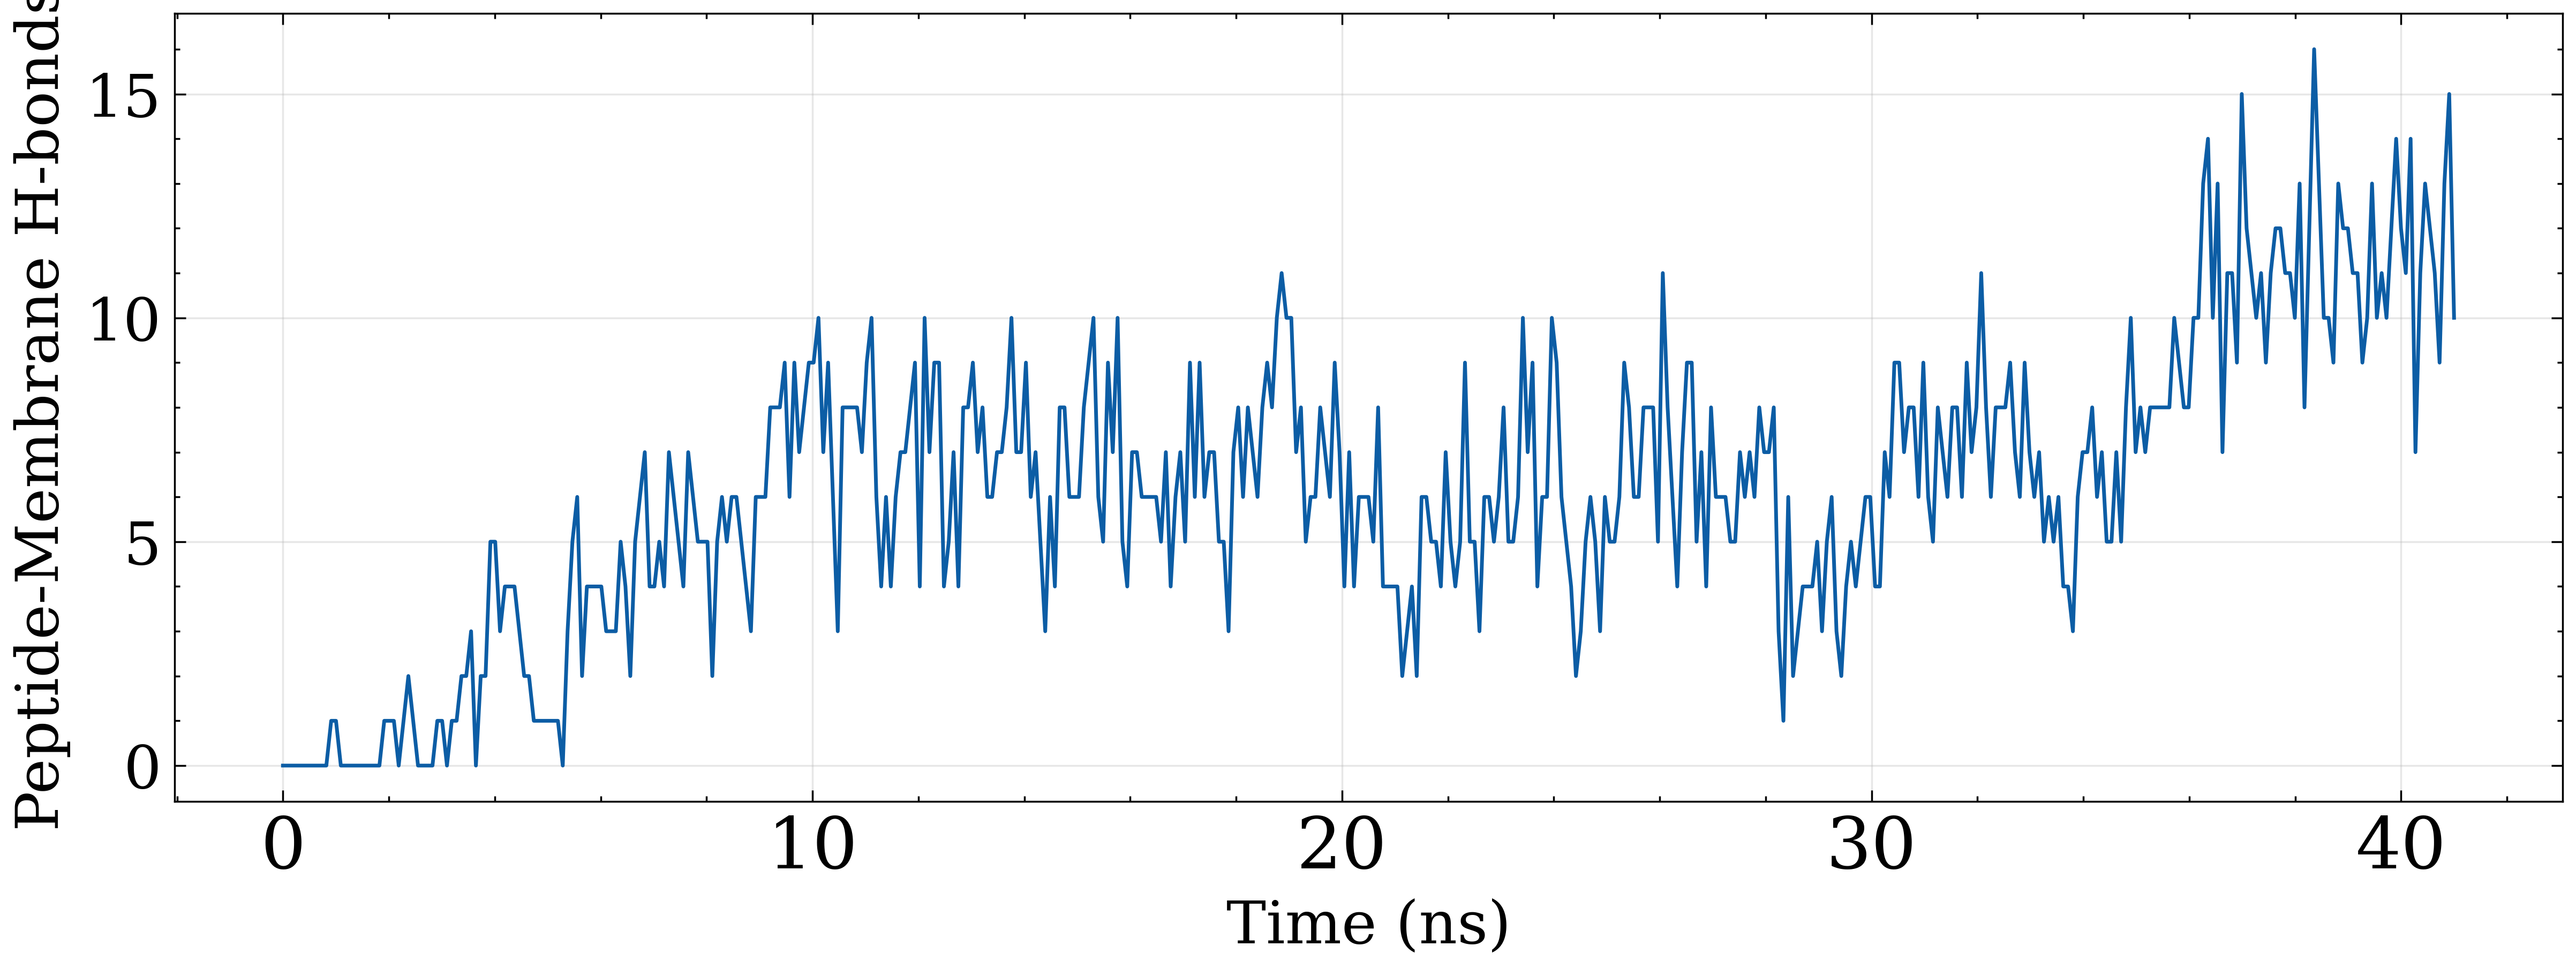

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
times_corrected = np.linspace(0, 41000, len(traj.time))  # Assuming total simulation time is 31,000 ps
plt.plot(times_corrected/1000, counts)

plt.xlabel("Time (ns)")
plt.ylabel("Peptide-Membrane H-bonds")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Plot everything

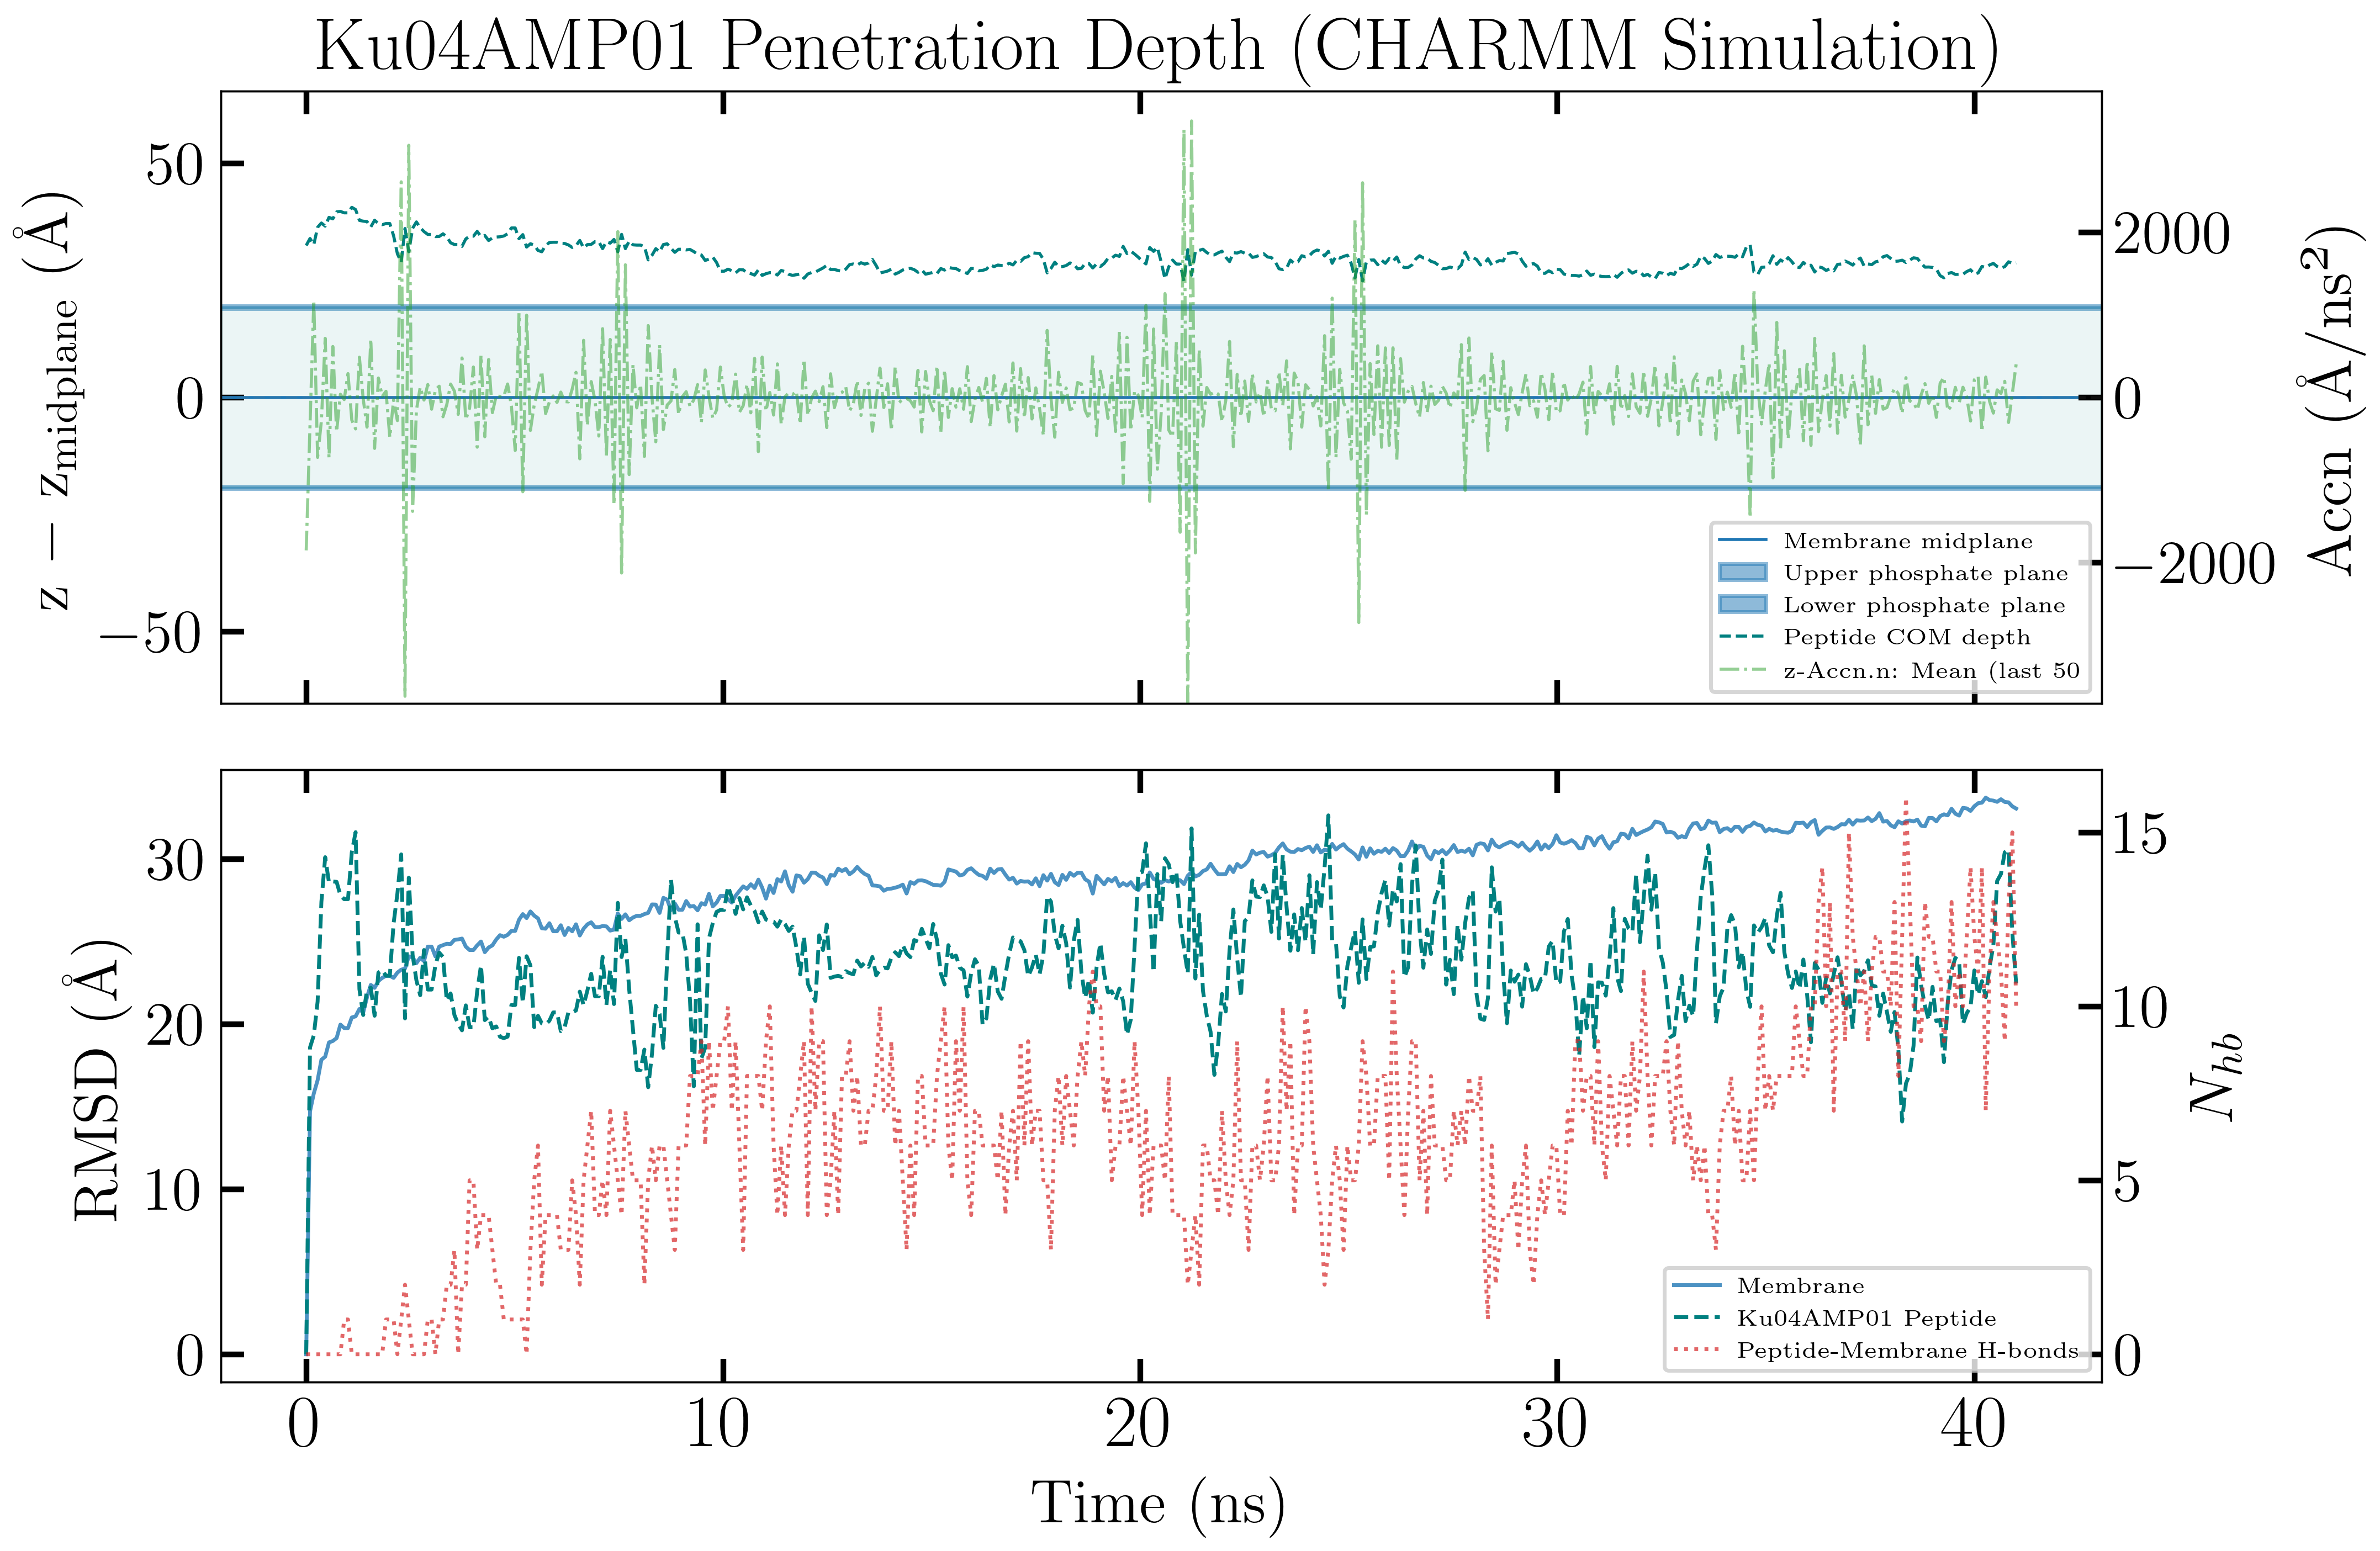

In [44]:
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = True
t_ns = corrected_times / 1000

fig, (ax_up, ax_down) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, tight_layout=True, gridspec_kw={'height_ratios': [1, 1]})

ax = ax_up  # Use the lower axis for plotting
# Mark the membrane center line
ax.axhline(0, color="tab:blue", lw=0.8, label="Membrane midplane")

# UPDATED: Verified Phosphorus headgroup planes
upper_p = dz_p_upper.mean()
lower_p = dz_p_lower.mean()

upper_p_std = dz_p_upper.std()
lower_p_std = dz_p_lower.std()
ax.axhspan(upper_p - upper_p_std, upper_p + upper_p_std, alpha=0.5, color="tab:blue", label="Upper phosphate plane")
ax.axhspan(lower_p - lower_p_std, lower_p + lower_p_std, alpha=0.5, color="tab:blue", label="Lower phosphate plane")

ax.axhspan(lower_p, upper_p, alpha=0.08, color="teal")

# Plot the Peptide depth
ax.plot(t_ns, dz_ku04, lw=0.8, color="teal", label="Peptide COM depth", ls="--")

ax.set_title("Ku04AMP01 Penetration Depth (CHARMM Simulation)")
ax.set_ylabel(r"z − z$_{\text{midplane}}$ (Å)")
ax.minorticks_off()
ax_ylim = np.sort(list(ax.get_ylim())) * 1.5
ax.set_ylim(-ax_ylim[1], ax_ylim[1])

# Add a secondary y-axis to show acceleration of penetration depth (optional)
ax2_up = ax.twinx()
ax2_up.minorticks_off()

# Get derivativs after spline interpolation
spline = UnivariateSpline(t_ns, dz_ku04, s=0)
dz_ku04_dt = spline.derivative(n=1)(t_ns)
dz_ku04_d2t = spline.derivative(n=2)(t_ns)

# Calculate mean and std over only the last 50% of the simulation
last_50_percent_mask = t_ns >= (t_ns[-1] - 0.5 * (t_ns[-1] - t_ns[0]))
mean_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].mean()
std_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].std()


ax2_up.plot(t_ns, dz_ku04_d2t, lw=0.8, color="tab:green", alpha=0.5, label=f"z-Accn.n: Mean (last 50%) ({mean_accel_last_50_percent:.2f} ± {std_accel_last_50_percent:.2f}) Å/ns²", ls="-.")
ax2_up.axhline(dz_ku04_d2t.mean(), color="gray", lw=0.8, ls="--", alpha=0.1)
ax2_up.set_ylabel(r"Accn (Å/ns²)")
# Align the zeros of ax and ax2
ax2_up_ylim = np.sort(list(ax2_up.get_ylim()))
ax2_up.set_ylim(-ax2_up_ylim[1], ax2_up_ylim[1])

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2_up.get_legend_handles_labels()
ax2_up.legend(lines + lines2, labels + labels2, loc="lower right", fontsize=6, frameon=True, fancybox=True)


ax = ax_down
ax.minorticks_off()
ax.set_xlabel("Time (ns)")
ax.plot(t_ns, np.array(rmsd_memb), label="Membrane", alpha=0.8, color="tab:blue")
ax.plot(t_ns, np.array(rmsd_ku04), label="Ku04AMP01 Peptide", color="teal", ls="--")
ax.set_ylabel("RMSD (Å)")

ax2_down = ax.twinx()
ax2_down.minorticks_off()
times_corrected = np.linspace(0, 30000, len(traj.time))  # Assuming total simulation time is 30,000 ps
ax2_down.plot(t_ns, counts, label="Peptide-Membrane H-bonds", color="tab:red", alpha=0.7, ls=":")
ax2_down.set_ylabel(r"$N_{hb}$")

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2_down.get_legend_handles_labels()
ax2_down.legend(lines + lines2, labels + labels2, loc="lower right", fontsize=6, frameon=True, fancybox=True)

for ax in [ax_up, ax_down, ax2_down, ax2_up]:
    ax.tick_params(axis='both', which='major', length=6, width=1.5)


plt.show()

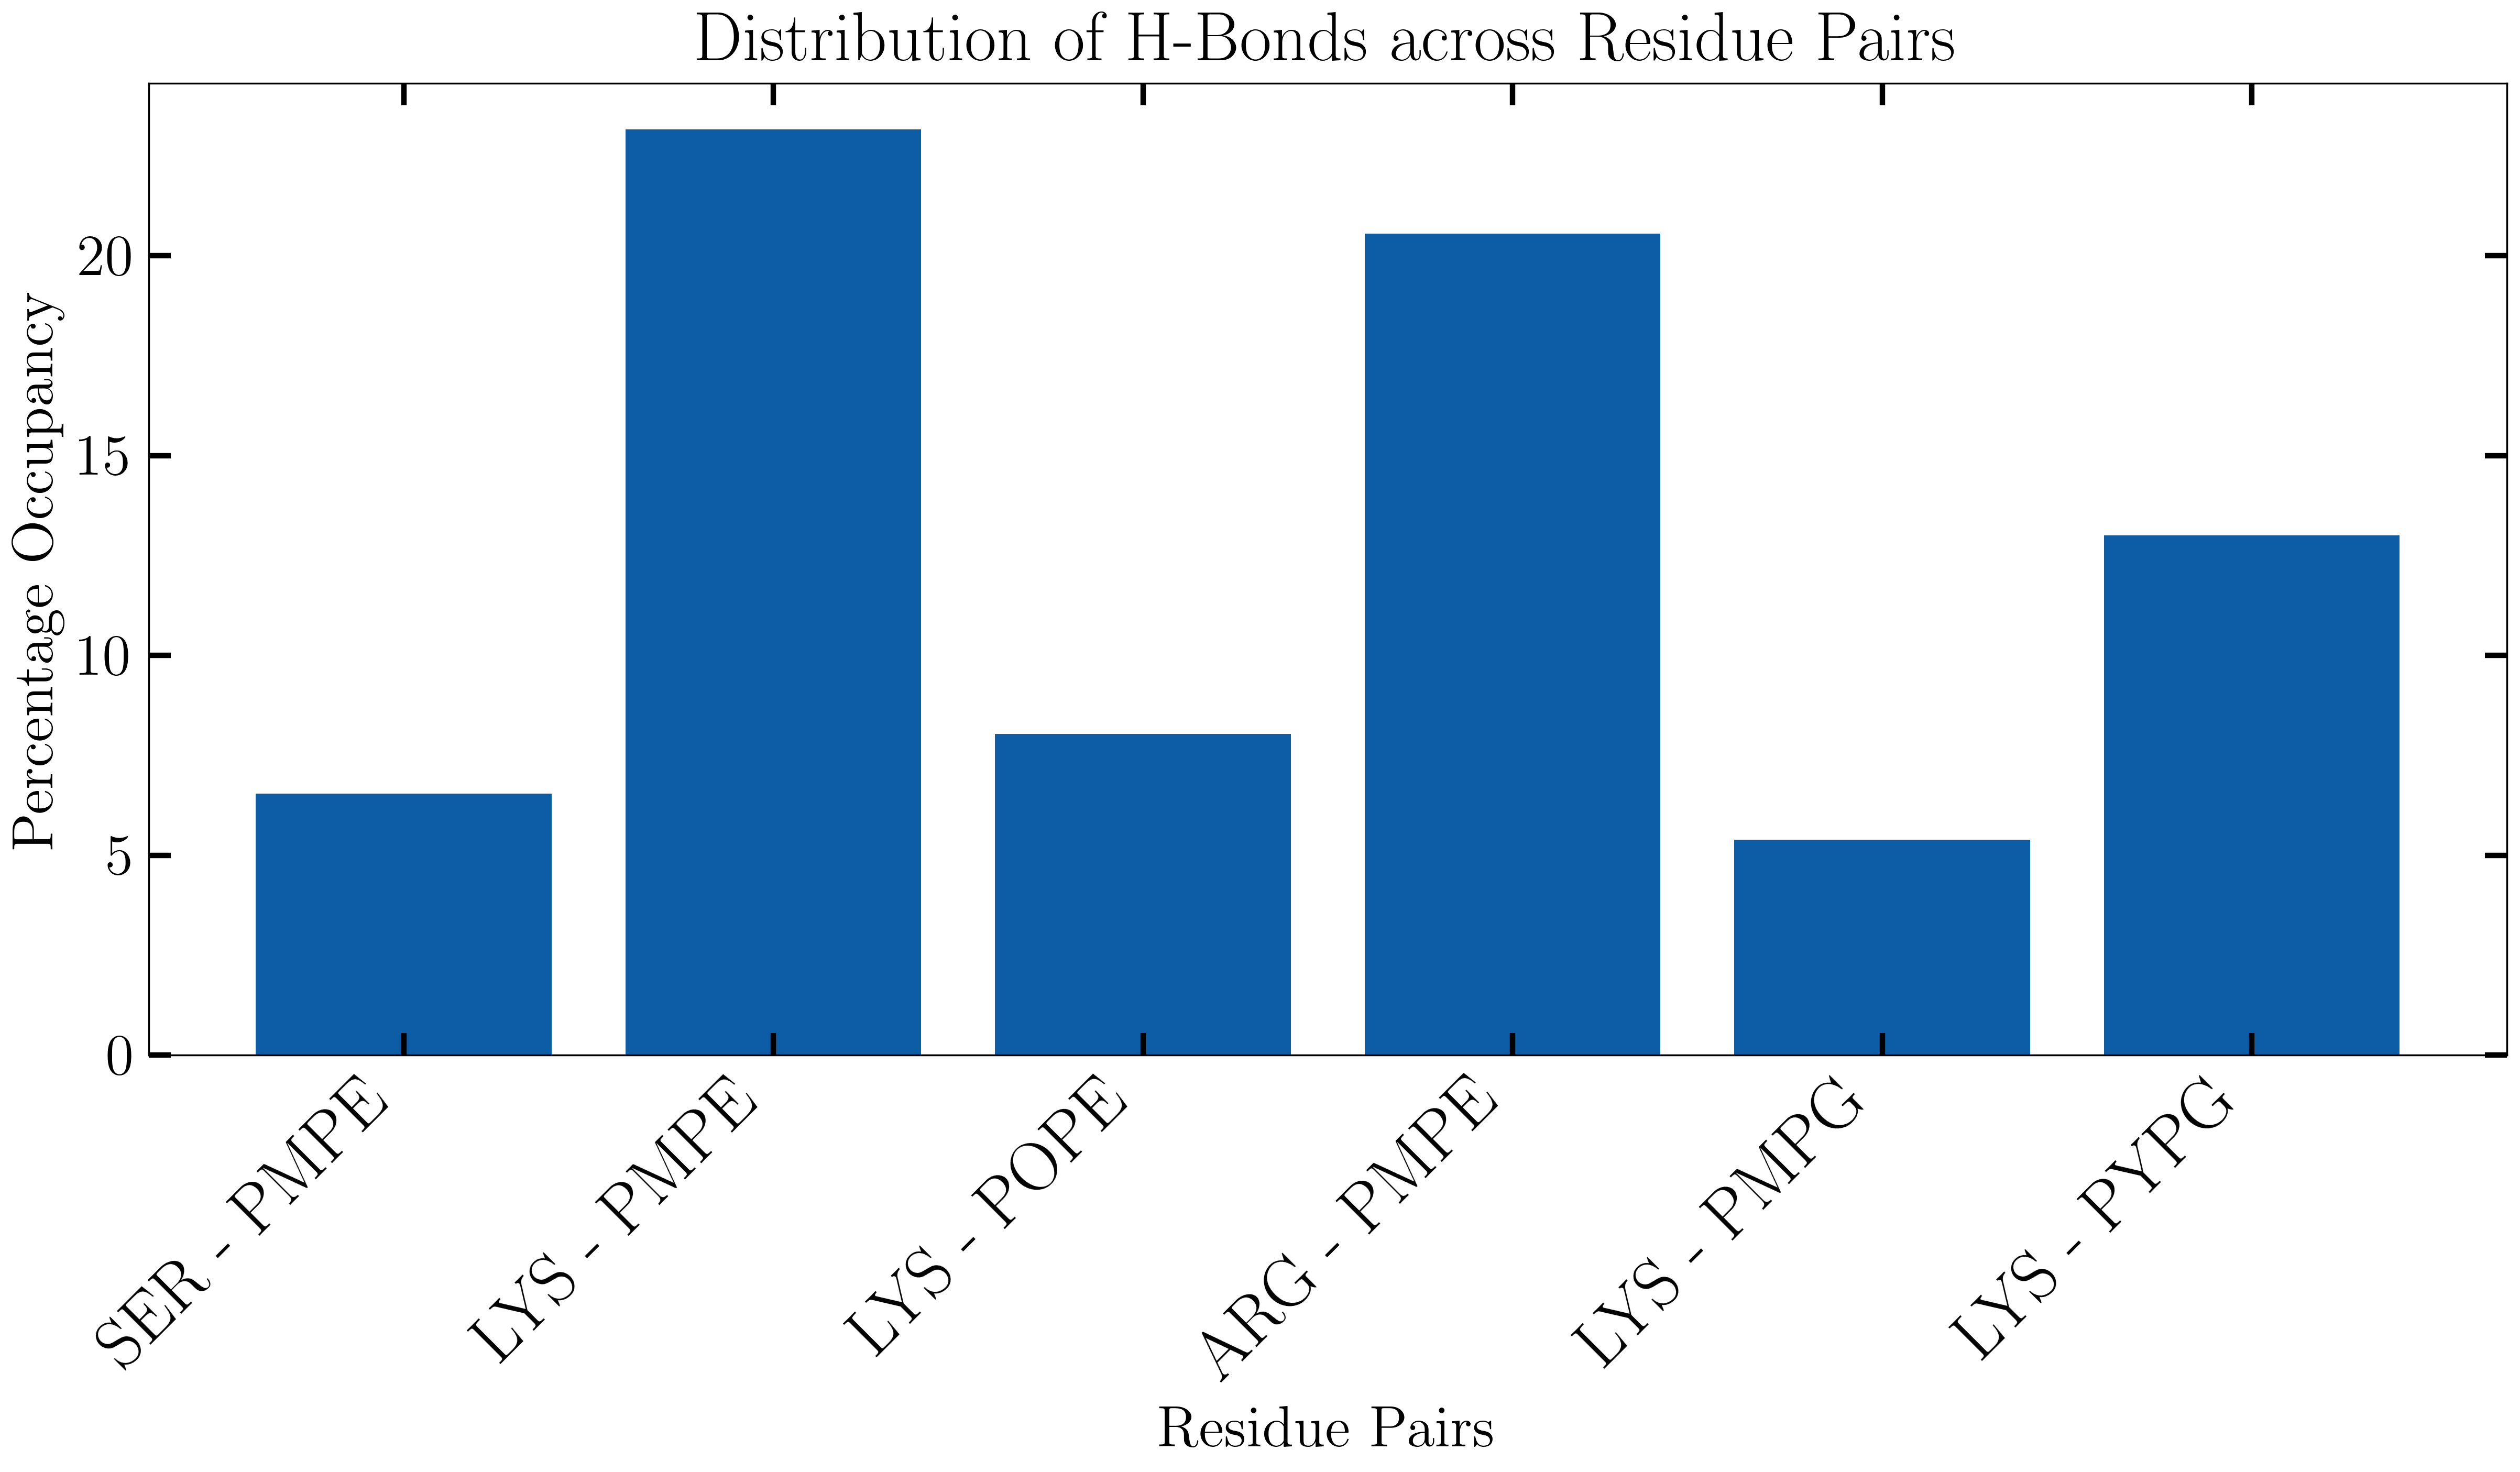

In [45]:
# Get residue names from hbonds
residues = set()
for hb in all_hbonds:
    residues.add((hb['donor_resname'], hb['acceptor_resname']))
residues = sorted(residues)

# Find the percentage of bonds for each residue pair
residue_counts = {}
for hb in all_hbonds:
    pair = (hb['donor_resname'], hb['acceptor_resname'])
    if pair not in residue_counts:
        residue_counts[pair] = 0
    residue_counts[pair] += 1

# Normalize by total number of bonds to get ratios
total_bonds = len(all_hbonds)
residue_percentages = {pair: (count / total_bonds) * 100 for pair, count in residue_counts.items()}

cutoff_percentage = 5
filtered_residue_percentages = {pair: percentage for pair, percentage in residue_percentages.items() if percentage >= cutoff_percentage}

# Plot the percentages as a histogram
import matplotlib.pyplot as plt

# Change the x data to "resname - resname" 
for pair in list(filtered_residue_percentages.keys()):
    new_key = f"{pair[0]} - {pair[1]}"
    filtered_residue_percentages[new_key] = filtered_residue_percentages.pop(pair)

fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)
ax.bar(range(len(filtered_residue_percentages)), list(filtered_residue_percentages.values()))
ax.set_xlabel('Residue Pairs')
ax.set_ylabel('Percentage Occupancy')
ax.set_title('Distribution of H-Bonds across Residue Pairs')
ax.set_xticks(range(len(filtered_residue_percentages)))
ax.set_xticklabels(list(filtered_residue_percentages.keys()), rotation=45, ha='right')
ax.minorticks_off()
ax.tick_params(axis='both', which='major', length=6, width=1.5)
plt.show()

## Profiling initial conditions

In [46]:
import MDAnalysis as mda
from MDAnalysis import transformations as trans
from tqdm.notebook import tqdm

u = mda.Universe(os.path.join(data_dir, "step7_1.tpr"), os.path.join(data_dir, "traj_prod.xtc"),os.path.join(data_dir, "step7_11_100ns.part0002.xtc"))
ku04_sel = "not (resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL W WF SOL ION NA SOD CL CLA TIP3)"

# If using martini, select by inclusion of standard Martini 3 membrane residues
# Example: memb_sel = "resname POPE OYPE PYPG PVCL2 DPPE DPPG"
#memb_sel = "resindex 36-235"
memb_sel = "resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL"
# Reload universe with center_in_box + wrap (no unwrap: that needs sequential
# reads from frame 0 and is incompatible with block-parallel random access).
# traj_whole.xtc is already molecule-whole, so this is sufficient.
membrane = u.select_atoms(memb_sel)
ku04     = u.select_atoms(ku04_sel)
workflow = [
    trans.unwrap(ku04),                                   # make ku04 whole (sequential, cumulative)
    trans.center_in_box(membrane, wrap=True),             # center membrane in box
    trans.wrap(u.select_atoms("all"), compound="fragments"),  # wrap by bonded fragment — peptide moves as one unit
]
u.trajectory.add_transformations(*workflow)


# Perform the transformations and dump the transformed trajectory to a new file
transformed_traj_file = os.path.join(data_dir, "traj_transformed.xtc")
with mda.Writer(transformed_traj_file, u.atoms.n_atoms) as W:
    for ts in tqdm(u.trajectory):
        W.write(u.atoms)

  0%|          | 0/451 [00:00<?, ?it/s]

In [50]:
import numpy as np
from tabulate import tabulate

# Ensure we are at frame 0
u.trajectory[0]

# Dump the initial frame as a PDB. 
u.atoms.write("initial_frame.pdb")

# Determine and tabulate the orientation of the peptide wrt the membrane plane, as well as box vectors, size, shape

ku04     = u.select_atoms(ku04_sel)
membrane = u.select_atoms(memb_sel)

# ── Box vectors ──────────────────────────────────────────────────────────────
box = u.dimensions   # [Lx, Ly, Lz, α, β, γ]
alpha, beta, gamma = box[3], box[4], box[5]

if np.allclose([alpha, beta, gamma], [90, 90, 90], atol=0.5):
    shape = "Orthorhombic"
elif np.allclose([alpha, beta], [90, 90], atol=0.5) and np.isclose(gamma, 120, atol=0.5):
    shape = "Hexagonal"
else:
    shape = "Triclinic"

box_rows = [
    ["Lx",     f"{box[0]:.3f} Å"],
    ["Ly",     f"{box[1]:.3f} Å"],
    ["Lz",     f"{box[2]:.3f} Å"],
    ["α",      f"{alpha:.2f}°"],
    ["β",      f"{beta:.2f}°"],
    ["γ",      f"{gamma:.2f}°"],
    ["Shape",  shape],
    ["Volume", f"{np.prod(box[:3])/1000:.3f} nm³"],
]

print("=== Box (Frame 0) ===")
print(tabulate(box_rows, headers=["Property", "Value"], tablefmt="github"))
print()

# ── Peptide axial orientation ────────────────────────────────────────────────
# principal_axes() returns eigenvectors sorted by eigenvalue (smallest first).
# Row 0 = longest molecular axis (smallest moment of inertia).
membrane_normal = np.array([0.0, 0.0, 1.0])   # z is the bilayer normal

pa = ku04.principal_axes()   # shape (3, 3)

def angle_vs_z(vec):
    """Acute angle between vec and the z-axis (degrees)."""
    v = vec / np.linalg.norm(vec)
    return np.degrees(np.arccos(np.clip(np.abs(np.dot(v, membrane_normal)), 0, 1)))

tilt_from_z     = angle_vs_z(pa[0])
tilt_from_plane = 90.0 - tilt_from_z   # measured from the membrane plane (0° = lying flat)

ku04_com = ku04.center_of_mass()
memb_com = membrane.center_of_mass()
dz       = ku04_com[2] - memb_com[2]

orient_rows = [
    ["Peptide COM",                f"({ku04_com[0]:.2f}, {ku04_com[1]:.2f}, {ku04_com[2]:.2f}) Å"],
    ["Membrane COM z",             f"{memb_com[2]:.2f} Å"],
    ["Δz (peptide − membrane)",    f"{dz:.2f} Å"],
    ["Longest axis (PA1)",         f"({pa[0][0]:.3f}, {pa[0][1]:.3f}, {pa[0][2]:.3f})"],
    ["PA1 angle vs z-axis",        f"{tilt_from_z:.2f}°"],
    ["PA1 tilt from membrane plane", f"{tilt_from_plane:.2f}°  {'(inserted/upright)' if tilt_from_plane > 45 else '(surface/parallel)'}"],
    ["PA2 angle vs z-axis",        f"{angle_vs_z(pa[1]):.2f}°"],
    ["PA3 angle vs z-axis",        f"{angle_vs_z(pa[2]):.2f}°"],
]

print("=== Ku04AMP01 Orientation (Frame 0) ===")
print(tabulate(orient_rows, headers=["Property", "Value"], tablefmt="github"))


=== Box (Frame 0) ===
| Property   | Value        |
|------------|--------------|
| Lx         | 78.132 Å     |
| Ly         | 78.132 Å     |
| Lz         | 106.973 Å    |
| α          | 90.00°       |
| β          | 90.00°       |
| γ          | 90.00°       |
| Shape      | Orthorhombic |
| Volume     | 653.036 nm³  |

=== Ku04AMP01 Orientation (Frame 0) ===
| Property                     | Value                      |
|------------------------------|----------------------------|
| Peptide COM                  | (53.85, 39.06, 85.94) Å    |
| Membrane COM z               | 53.50 Å                    |
| Δz (peptide − membrane)      | 32.43 Å                    |
| Longest axis (PA1)           | (0.010, 0.052, 0.999)      |
| PA1 angle vs z-axis          | 3.01°                      |
| PA1 tilt from membrane plane | 86.99°  (inserted/upright) |
| PA2 angle vs z-axis          | 87.06°                     |
| PA3 angle vs z-axis          | 89.32°                     |
